In [1]:
import starry
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import pymc3.math as pmm
import pymc3_ext as pmx
import exoplanet
from starry_process import StarryProcess, MCMCInterface
from starry_process.math import cho_factor, cho_solve
import starry_process 
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import aesara_theano_fallback.tensor as tt
from theano.tensor.slinalg import cholesky
from corner import corner
import arviz as az
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import os
from tqdm import tqdm
from theano.tensor.random.utils import RandomStream
import scipy.linalg as sl
import scipy.stats as ss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import lightkurve as lk
import pandas as pd
import seaborn as sns

starry.config.quiet = True
np.random.seed(1)

import warnings

# Ignore all warnings (not recommended, might hide other important warnings)
warnings.filterwarnings("ignore")

# Ignore specific warning by type
warnings.filterwarnings("ignore", message="Cannot construct a scalar test value from a test value with no size")

# Set logging level to ignore these warnings (recommended)
import logging
logger = logging.getLogger("theano.tensor.opt")
logger.setLevel(logging.ERROR)


WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/sabina/.lightkurve/cache. Please move all the files in the legacy directory /Users/sabina/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [21]:
import sys
sys.path.insert(1, '/Users/sabina/Desktop/GitHub/starry-project/scripts')

from starry_starry_process import StarryStarryProcess

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.map import Map
from sunpy.net import Fido, attrs as a
import astropy.time
from astropy.visualization import ImageNormalize, SqrtStretch
import matplotlib.colors as colors

# Define solar maximum timeframe (approximately 2014 for Solar Cycle 24 or 2023-2024 for Cycle 25)
# Using a date from solar maximum of Cycle 24
solar_max_time = astropy.time.Time('2014-02-15T00:00:00')

# Query SDO data - we'll use AIA 171 Å data as an example
query = Fido.search(
    a.Time(solar_max_time, solar_max_time + 1*u.hour),
    a.Instrument.aia,
    a.Wavelength(171*u.angstrom)
)

# Download the data (or point to local file if already downloaded)
downloaded_files = Fido.fetch(query)
sdo_map = Map(downloaded_files[0])

# Reproject the data into Mollweide projection
# First convert to Carrington coordinates (heliographic)
header = sdo_map.meta.copy()

# Create meshgrid of original pixel coordinates
x, y = np.meshgrid(*[np.arange(v.value) for v in sdo_map.dimensions])


Files Downloaded:   0%|          | 0/300 [00:00<?, ?file/s]

2025-03-28 15:51:39 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1171499303-1171499303 failed to download with exception

2025-03-28 15:51:39 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1171499315-1171499315 failed to download with exception

2025-03-28 15:51:39 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1171499327-1171499327 failed to download with exception

2025-03-28 15:51:39 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1171499339-1171499339 failed to download with exception

2025-03-28 15:51:39 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1171499351-1171499351 failed to download with exception



5/0 files failed to download. Please check `.errors` for details


In [3]:
downloaded_files

['/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_00_11_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_00_23_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_00_35_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_00_47_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_00_59_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_01_11_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_01_23_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_01_35_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_01_47_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_01_59_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_02_11_34z_image_lev1.fits', '/Users/sabina/sunpy/data/aia_lev1_171a_2014_02_15t00_02_23_34z_image_lev1.fits', '/Users/sabina/

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.map import Map
from sunpy.net import Fido, attrs as a
import astropy.time
from astropy.visualization import ImageNormalize, SqrtStretch
import matplotlib.colors as colors

# Set up queries to get views from different sides of the Sun with minimal files
# Instead of covering a full rotation, we'll use just 2-3 strategic observations

# First, use a date from the front side view
front_time = astropy.time.Time('2014-02-15T00:00:00')
# Then approximately 14 days later (half rotation) to get the opposite side
back_time = front_time + 14 * u.day

# Create separate queries for front and back
query_front = Fido.search(
    a.Time(front_time, front_time + 1*u.hour),
    a.Instrument.aia,
    a.Wavelength(171*u.angstrom)
)

query_back = Fido.search(
    a.Time(back_time, back_time + 1*u.hour),
    a.Instrument.aia,
    a.Wavelength(171*u.angstrom)
)

# Download just one file from each query
front_file = Fido.fetch(query_front[0, 0])  # Just the first result
back_file = Fido.fetch(query_back[0, 0])    # Just the first result

# Process just these two files
observation_files = [front_file[0], back_file[0]]  # Only 2 files

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Successfully converted 2966638 points to Carrington coordinates


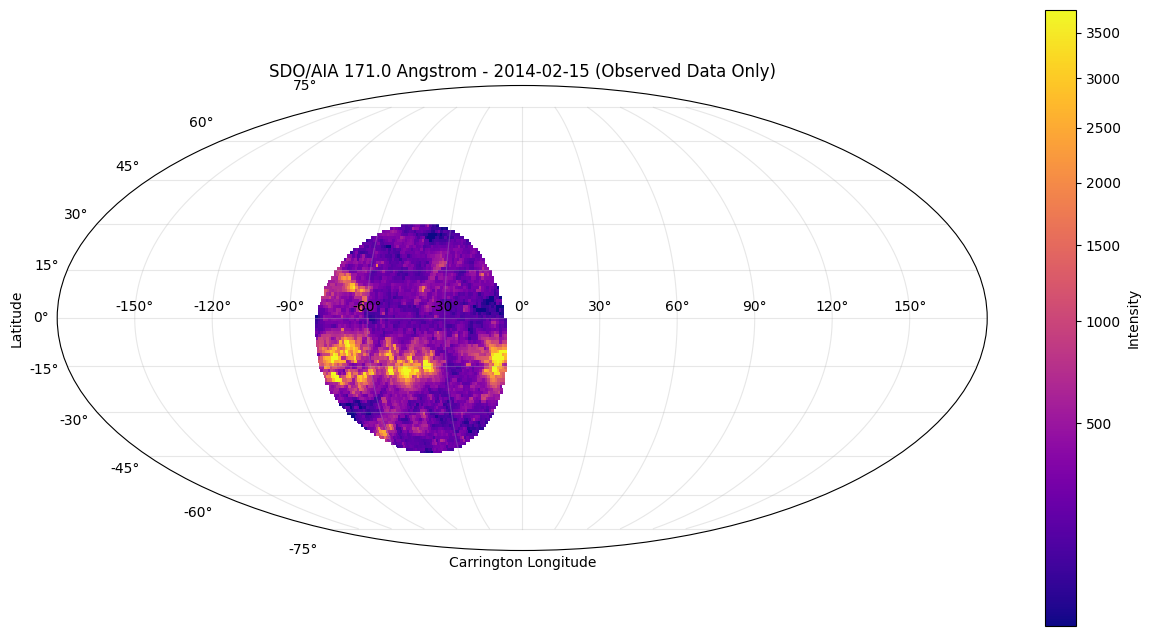

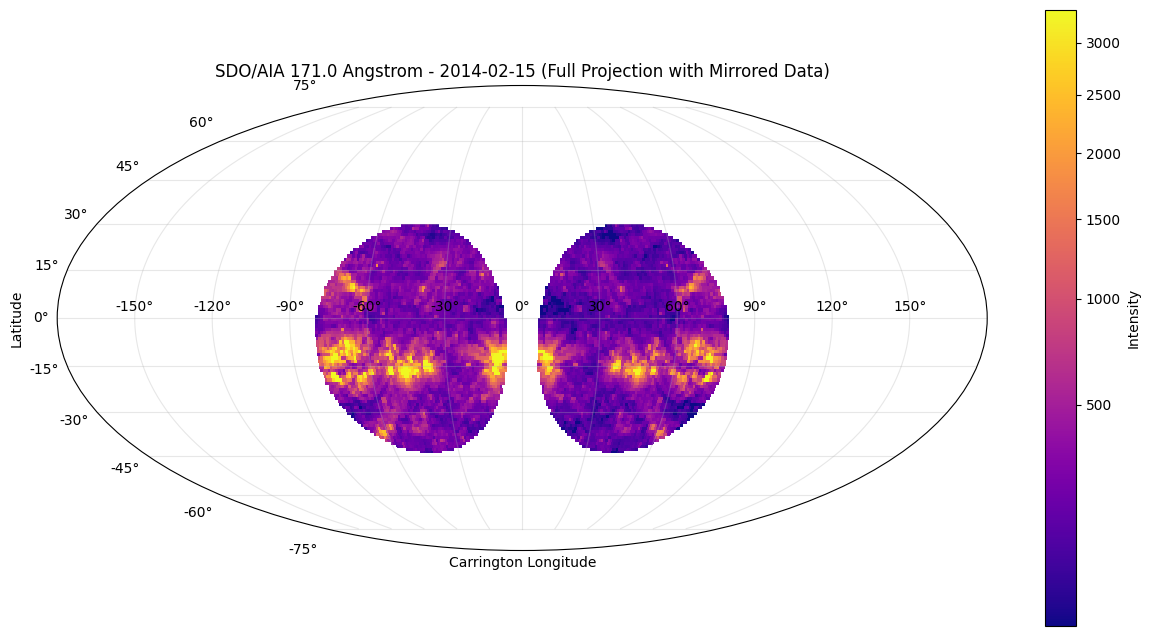

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.map import Map
from sunpy.net import Fido, attrs as a
import astropy.time
from astropy.visualization import ImageNormalize, SqrtStretch
import matplotlib.colors as colors

# Use a date from solar maximum of Cycle 24
time = astropy.time.Time('2014-02-15T00:00:00')

# Query and download a single AIA 171 Å image
query = Fido.search(
    a.Time(time, time + 1*u.hour),
    a.Instrument.aia,
    a.Wavelength(171*u.angstrom)
)

# Download just one file
downloaded_file = Fido.fetch(query[0, 0])
sdo_map = Map(downloaded_file[0])

# Create a regularly spaced Mollweide grid
lon_grid = np.linspace(-np.pi, np.pi, 360)  # 1 degree spacing in longitude
lat_grid = np.linspace(-np.pi/2, np.pi/2, 180)  # 1 degree spacing in latitude
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Initialize an empty array for intensity values
intensity_grid = np.full(lon_mesh.shape, np.nan)

# Create pixel coordinates for the map
y, x = np.mgrid[:sdo_map.data.shape[0], :sdo_map.data.shape[1]]

# Calculate the distance from disk center
center_x, center_y = sdo_map.reference_pixel.x.value, sdo_map.reference_pixel.y.value
radius = sdo_map.rsun_obs.value
distance = np.sqrt((x - center_x)**2 + (y - center_y)**2) / radius

# Mask solar disk 
disk_mask = distance <= 1.0

# Get coordinates for solar disk pixels
disk_x = x[disk_mask]
disk_y = y[disk_mask]

# Get data values for disk pixels
disk_values = sdo_map.data[disk_mask]

# Convert pixels to helioprojective coordinates
coords = sdo_map.pixel_to_world(disk_x * u.pixel, disk_y * u.pixel)

try:
    # Convert to Carrington coordinates
    carrington_coords = coords.transform_to("heliographic_carrington")
    
    # Get longitudes and latitudes in radians for Mollweide projection
    lons = carrington_coords.lon.wrap_at(180 * u.deg).rad
    lats = carrington_coords.lat.rad
    
    # Only keep valid coordinates
    valid_mask = np.isfinite(lons) & np.isfinite(lats) & np.isfinite(disk_values)
    lons = lons[valid_mask]
    lats = lats[valid_mask]
    values = disk_values[valid_mask]
    
    print(f"Successfully converted {len(lons)} points to Carrington coordinates")
    
    # Assign values to the Mollweide grid cells
    for i in range(len(lons)):
        # Find closest grid point
        lon_idx = np.argmin(np.abs(lon_grid - lons[i]))
        lat_idx = np.argmin(np.abs(lat_grid - lats[i]))
        
        # Set intensity value (use maximum if multiple points map to same grid cell)
        current_val = intensity_grid[lat_idx, lon_idx]
        if np.isnan(current_val) or values[i] > current_val:
            intensity_grid[lat_idx, lon_idx] = values[i]
    
    # Find which side of the Sun we're seeing
    visible_side = np.zeros(lon_mesh.shape, dtype=bool)
    # Identify which grid cells have data - these represent the visible side
    visible_side[np.isfinite(intensity_grid)] = True
    
    # Fill the far side by mirroring the visible side
    # Determine if we're seeing mostly the left or right half
    left_half_sum = np.sum(visible_side[:, :len(lon_grid)//2])
    right_half_sum = np.sum(visible_side[:, len(lon_grid)//2:])
    
    # Create a mirrored version of the intensity grid
    mirrored_grid = np.copy(intensity_grid)
    
    if left_half_sum > right_half_sum:
        # We're seeing mostly the left half, mirror to the right
        for i in range(len(lon_grid)//2):
            mirror_idx = len(lon_grid) - 1 - i
            mirrored_grid[:, mirror_idx] = intensity_grid[:, i] * 0.7  # Dampen mirrored values
    else:
        # We're seeing mostly the right half, mirror to the left
        for i in range(len(lon_grid)//2, len(lon_grid)):
            mirror_idx = len(lon_grid) - 1 - i + len(lon_grid)//2
            if mirror_idx < len(lon_grid):
                mirrored_grid[:, mirror_idx] = intensity_grid[:, i] * 0.7
    
    # Combine the original grid with mirrored parts where we have no data
    combined_grid = np.copy(intensity_grid)
    combined_grid[np.isnan(combined_grid)] = mirrored_grid[np.isnan(combined_grid)]
    
    # Create two plots: one with just the observed data and one with the full mirrored projection
    
    # Plot 1: Just the observed data
    plt.figure(figsize=(15, 8))
    ax1 = plt.subplot(111, projection='mollweide')
    
    valid_data = np.isfinite(intensity_grid)
    if np.any(valid_data):  # Make sure we have valid data
        norm = ImageNormalize(
            vmin=np.percentile(intensity_grid[valid_data], 1),
            vmax=np.percentile(intensity_grid[valid_data], 99),
            stretch=SqrtStretch()
        )
        
        im1 = ax1.pcolormesh(
            lon_mesh, lat_mesh, intensity_grid, 
            cmap=plt.cm.plasma, norm=norm
        )
        
        plt.colorbar(im1, ax=ax1, label='Intensity')
    
    ax1.grid(True, alpha=0.3)
    plt.title(f'SDO/AIA 171.0 Angstrom - {sdo_map.date.strftime("%Y-%m-%d")} (Observed Data Only)')
    plt.xlabel('Carrington Longitude')
    plt.ylabel('Latitude')
    
    plt.savefig('sdo_mollweide_observed_only.png', dpi=300, bbox_inches='tight')
    
    # Plot 2: Full projection with mirrored data
    plt.figure(figsize=(15, 8))
    ax2 = plt.subplot(111, projection='mollweide')
    
    valid_data = np.isfinite(combined_grid)
    if np.any(valid_data):  # Make sure we have valid data
        norm = ImageNormalize(
            vmin=np.percentile(combined_grid[valid_data], 1),
            vmax=np.percentile(combined_grid[valid_data], 99),
            stretch=SqrtStretch()
        )
        
        im2 = ax2.pcolormesh(
            lon_mesh, lat_mesh, combined_grid, 
            cmap=plt.cm.plasma, norm=norm
        )
        
        plt.colorbar(im2, ax=ax2, label='Intensity')
    
    ax2.grid(True, alpha=0.3)
    plt.title(f'SDO/AIA 171.0 Angstrom - {sdo_map.date.strftime("%Y-%m-%d")} (Full Projection with Mirrored Data)')
    plt.xlabel('Carrington Longitude')
    plt.ylabel('Latitude')
    
    plt.savefig('sdo_mollweide_full_projection.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"Error in coordinate transformation: {e}")
    
    # If transformation fails, plot just the original SDO map for reference
    plt.figure(figsize=(10, 10))
    sdo_map.plot()
    plt.title(f'Original SDO/AIA 171.0 Angstrom - {sdo_map.date.strftime("%Y-%m-%d")}')
    plt.savefig('original_sdo_map.png', dpi=300)
    plt.show()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Processing 2800411 valid points


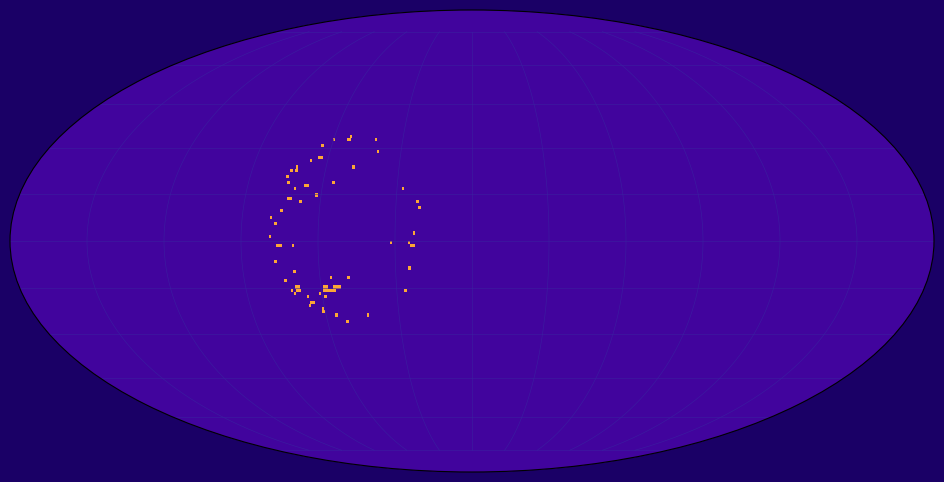

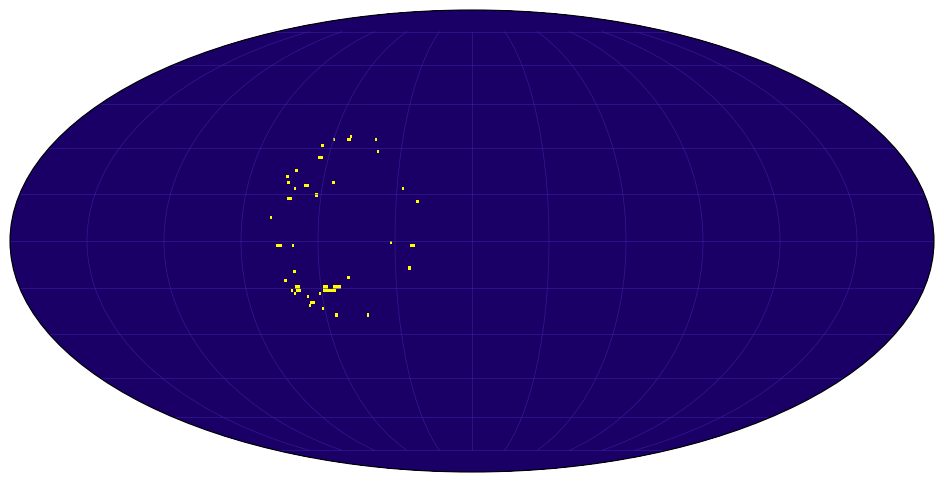

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from sunpy.map import Map
from sunpy.net import Fido, attrs as a
import astropy.time

# Use a date from the recent solar maximum (Cycle 25, 2023-2024)
time = astropy.time.Time('2023-07-15T00:00:00')  # Recent solar maximum period

# Query and download a continuum image (best for spotting sunspots)
# HMI continuum images are ideal for sunspot detection
query = Fido.search(
    a.Time(time, time + 1*u.hour),
    a.Instrument.hmi,
    a.Physobs.intensity
)

# Download the file
downloaded_file = Fido.fetch(query[0, 0])
sun_map = Map(downloaded_file[0])

# Create a regularly spaced Mollweide grid
lon_grid = np.linspace(-np.pi, np.pi, 360)
lat_grid = np.linspace(-np.pi/2, np.pi/2, 180)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
intensity_grid = np.full(lon_mesh.shape, np.nan)

# Create pixel coordinates for the map
y, x = np.mgrid[:sun_map.data.shape[0], :sun_map.data.shape[1]]

# Calculate the distance from disk center
center_x, center_y = sun_map.reference_pixel.x.value, sun_map.reference_pixel.y.value
radius = sun_map.rsun_obs.value
distance = np.sqrt((x - center_x)**2 + (y - center_y)**2) / radius

# Mask solar disk
disk_mask = distance <= 1.0
disk_x = x[disk_mask]
disk_y = y[disk_mask]
disk_values = sun_map.data[disk_mask]

# Convert pixels to world coordinates
coords = sun_map.pixel_to_world(disk_x * u.pixel, disk_y * u.pixel)

# Convert to Carrington coordinates
carrington_coords = coords.transform_to("heliographic_carrington")
lons = carrington_coords.lon.wrap_at(180 * u.deg).rad
lats = carrington_coords.lat.rad

# Keep only valid coordinates
valid_mask = np.isfinite(lons) & np.isfinite(lats) & np.isfinite(disk_values)
lons = lons[valid_mask]
lats = lats[valid_mask]
values = disk_values[valid_mask]

print(f"Processing {len(lons)} valid points")

# Map data to the Mollweide grid
for i in range(len(lons)):
    lon_idx = np.argmin(np.abs(lon_grid - lons[i]))
    lat_idx = np.argmin(np.abs(lat_grid - lats[i]))
    
    current_val = intensity_grid[lat_idx, lon_idx]
    if np.isnan(current_val) or values[i] < current_val:  # For sunspots, we want the darkest points
        intensity_grid[lat_idx, lon_idx] = values[i]

# Calculate intensity threshold for sunspot detection
# Sunspots are typically darker than the surrounding photosphere
threshold = np.nanmean(intensity_grid) - 1.5 * np.nanstd(intensity_grid)

# Create a binary mask for sunspots (1 for sunspots, 0 for everything else)
sunspot_mask = np.full(intensity_grid.shape, 0.0)
sunspot_mask[intensity_grid < threshold] = 1.0

# Optionally, apply some smoothing to the binary mask
from scipy.ndimage import gaussian_filter
sunspot_mask = gaussian_filter(sunspot_mask, sigma=0.5)

# Create a Mollweide projection with deep purple background and keeping the original spot appearance
plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection='mollweide')

# Define the deep purple background color from the reference image
deep_purple = '#1A0066'  # Deep purple background
grid_color = '#3A20A0'   # Slightly lighter purple for grid lines

# Start with everything as the deep purple background
filled_grid = np.full(lon_mesh.shape, 0.1)  # Low value for plasma colormap

# Now highlight the sunspots as bright areas (keeping this as it was)
sunspot_mask = intensity_grid < threshold
filled_grid[sunspot_mask] = 0.8  # Bright yellow in plasma colormap

# Plot with plasma colormap (unchanged for spots)
im = ax.pcolormesh(
    lon_mesh, lat_mesh, filled_grid,
    cmap='plasma',
    vmin=0, vmax=1
)

# Add grid matching the reference image
ax.grid(True, color=grid_color, alpha=0.8, linestyle='-', linewidth=0.5)

# Remove tick labels but keep the grid
ax.set_xticklabels([])
ax.set_yticklabels([])

# Make the plot background match the deep purple from reference
ax.set_facecolor(deep_purple)
plt.gcf().set_facecolor(deep_purple)

# Save the figure
plt.savefig('purple_background_with_original_spots.png', dpi=300, bbox_inches='tight', 
            facecolor=deep_purple, edgecolor='none')
plt.show()
plt.show()

# Alternative simple approach using a direct match to the reference image colors
plt.figure(figsize=(12, 6))
ax = plt.subplot(111, projection='mollweide')

# Define specific colors from the reference image
deep_purple = '#1A0066'  # Deep purple background
grid_color = '#3A20A0'   # Slightly lighter purple for grid lines
spot_color = '#FF3300'   # Bright reddish-orange for spots
bright_spot = '#FFFF00'  # Bright yellow for the brightest spots

# Start with all deep purple background
filled_grid = np.full(lon_mesh.shape, 0)  # Will be mapped to deep purple

# Make sunspots bright colors
# Different intensities of sunspots get different colors
strong_spots = intensity_grid < (threshold - 0.15 * np.nanstd(intensity_grid))
medium_spots = (intensity_grid >= (threshold - 0.15 * np.nanstd(intensity_grid))) & (intensity_grid < threshold)

# Assign values that will map to our colors
filled_grid[medium_spots] = 0.5  # Will map to orange-red
filled_grid[strong_spots] = 1.0   # Will map to bright yellow

# Create a custom colormap that exactly matches the reference image
from matplotlib.colors import LinearSegmentedColormap
colors = [(deep_purple, spot_color, bright_spot)]
colors_rgb = []

# Convert hex colors to RGB tuples
for color_set in colors:
    rgb_set = []
    for c in color_set:
        # Convert hex to RGB
        rgb_set.append((int(c[1:3], 16)/255, int(c[3:5], 16)/255, int(c[5:7], 16)/255))
    colors_rgb.append(rgb_set)

# Create a colormap with exactly these colors
cdict = {
    'red': [(0.0, colors_rgb[0][0][0], colors_rgb[0][0][0]),
            (0.5, colors_rgb[0][1][0], colors_rgb[0][1][0]),
            (1.0, colors_rgb[0][2][0], colors_rgb[0][2][0])],
    'green': [(0.0, colors_rgb[0][0][1], colors_rgb[0][0][1]),
              (0.5, colors_rgb[0][1][1], colors_rgb[0][1][1]),
              (1.0, colors_rgb[0][2][1], colors_rgb[0][2][1])],
    'blue': [(0.0, colors_rgb[0][0][2], colors_rgb[0][0][2]),
             (0.5, colors_rgb[0][1][2], colors_rgb[0][1][2]),
             (1.0, colors_rgb[0][2][2], colors_rgb[0][2][2])]
}
custom_cmap = LinearSegmentedColormap('CustomMap', cdict)

# Plot with custom colormap
im = ax.pcolormesh(
    lon_mesh, lat_mesh, filled_grid,
    cmap=custom_cmap,
    vmin=0, vmax=1
)

# Add grid matching the reference image
ax.grid(True, color=grid_color, alpha=0.8, linestyle='-', linewidth=0.5)

# Remove tick labels but keep the grid
ax.set_xticklabels([])
ax.set_yticklabels([])

# Make the plot background match the deep purple
ax.set_facecolor(deep_purple)

# Save the figure
plt.savefig('exact_color_match_mollweide.png', dpi=300, bbox_inches='tight', 
            facecolor=deep_purple, edgecolor='none')
plt.show()

In [22]:
import sys
sys.path.insert(1, '/Users/sabina/Desktop/GitHub/starry-project/scripts')

from starry_starry_process import StarryStarryProcess

In [23]:
def Inclination(name, testval=30):
    """
    An isotropic distribution for inclination angles (in degrees).
    
    """
    def logp(x):
        return tt.log(np.pi / 180 * tt.sin(x * np.pi / 180))

    def random(*args, **kwargs):
        return tt.arccos(pm.Uniform.dist(0, 1).random(*args, **kwargs)) * 180 / np.pi

    return pm.DensityDist(
        name,
        logp,
        random=random,
        initval=testval,
    )

def Angle(*args, **kwargs):
    """
    A uniform distribution for angles in [-180, 180).
    
    """
    if kwargs.get("testval", None) is not None:
        kwargs["testval"] *= np.pi / 180
    return 180 / np.pi * pmx.Angle(*args, **kwargs)

def Planet_Inc(name, *args, **kwargs):
    bmax = params[name].get('bmax')
    b = pm.Uniform('b', -bmax, bmax)
    planet_inc = pm.Deterministic(name, 180.0/np.pi*np.arccos(b))
    
    return planet_inc

def Planet_w(name, *args, **kwargs):
    w_x = pm.Normal('w_x', mu=0, sigma=1, testval=1)
    w_y = pm.Normal('w_y', mu=0, sigma=1, testval=1)
    planet_w = pm.Deterministic(name, 180.0/np.pi*tt.arctan2(w_y, w_x))
    
    return planet_w

def xyz_transform(x_, y_, z_):
    x = x_
    y = (np.sqrt(2)/2) * (z_ + y_)
    z = (np.sqrt(2)/2) * (z_ - y_)

    return x, y, z

def xyz_transform_back(x, y, z):
    x_ = x
    y_ = (np.sqrt(2)/2) * (y - z)
    z_ = (np.sqrt(2)/2) * (y + z)

    return x_, y_, z_

def Stellar_Ori():
    stellar_ori_x_ = pm.Normal('stellar_ori_x_', mu=0, sigma=1, testval=1)
    stellar_ori_y_ = pm.Normal('stellar_ori_y_', mu=0, sigma=1, testval=1)
    stellar_ori_z_ = pm.HalfNormal('stellar_ori_z_', sigma=1, testval=1)

    stellar_ori_x, stellar_ori_y, stellar_ori_z = xyz_transform(stellar_ori_x_, stellar_ori_y_, stellar_ori_z_)

    stellar_obl = pm.Deterministic('star.obl', 180.0/np.pi*tt.arctan2(stellar_ori_y, stellar_ori_x))
    stellar_inc = pm.Deterministic('star.inc', 180.0/np.pi*tt.arccos(stellar_ori_z / tt.sqrt(tt.square(stellar_ori_x) + tt.square(stellar_ori_y) + tt.square(stellar_ori_z))))
    
    return stellar_inc, stellar_obl
    # if "inc" in name:
    #     return stellar_inc
    
    # elif "obl" in name:
    #     return stellar_obl

def Period(name, *args, **kwargs):
    Ttotal = t[-1] - t[0]
    frac_bounds = params[name].get('frac_bounds')

    if kwargs.get("testval", None) is not None:
        trueval = kwargs["testval"]

    def logp(trueval, frac_bounds):
        return pm.Uniform(name+'logp',tt.log(trueval) + np.log1p(-frac_bounds), tt.log(trueval) + np.log1p(frac_bounds))

    period = pm.Deterministic(name, tt.exp(logp(trueval, frac_bounds)))

    return period

def Logarithmic(name, *args, **kwargs):
    if kwargs.get("testval", None) is not None:
        trueval = kwargs["testval"]
    log_rp = pm.Uniform(name+'log', tt.log(trueval/2), tt.log(2*trueval))
    rp = pm.Deterministic(name, tt.exp(log_rp))

    return rp

# Shorthand for the usual Uniform distribution
Uniform = pm.Uniform

In [69]:
def gp_model(t, flux, sigma_flux, params):
    # Helper function to instantiate parameters
    def parameter(name):
        param = params[name]
        if param.get("free", False):
            args = param.get("args", [])
            kwargs = param.get("kwargs", {})
            testval = param.get("testval", param["truth"])
            return param["dist"](name, *args, testval=testval, **kwargs)
            
        else:
            return param["truth"]
    
    starry.config.lazy = True
        
    with pm.Model() as model:

        prot = parameter('star.prot')

        porb = parameter('planet.porb')
        t0 = parameter('planet.t0')
        rp = parameter('planet.r')
        planet_inc = parameter('planet.inc')
        mp = parameter('planet.m')
        ecc = parameter('planet.ecc')
        Omega = parameter('planet.Omega')
        w = parameter('planet.w')

        map_model = starry.Map(ydeg=6, udeg=2)

        # stellar_inc, stellar_obl = Stellar_Ori()
        map_model.inc = parameter('star.inc')
        map_model.obl = parameter('star.obl')
        # map_model.inc = stellar_inc
        # map_model.obl = stellar_obl
        
        map_model[1] = parameter('star.u1')
        map_model[2] = parameter('star.u2')
        
        pri_model = starry.Primary(map_model, 
            r=parameter('star.r'), 
            m=parameter('star.m'), 
            prot=prot)

        sec_model = starry.kepler.Secondary(starry.Map(0,0), 
            t0=t0, 
            r=rp, 
            m=mp, 
            porb=porb, 
            ecc=ecc, 
            Omega=Omega, 
            inc=planet_inc,
            w=w)
    
        sys_model = starry.System(pri_model, sec_model)

        sp_model = StarryProcess(
            # a = parameter("gp.a"),
            # b = parameter("gp.b"),
            mu = parameter('gp.mu'),
            sigma = parameter('gp.sigma'),
            c = parameter("gp.c"),
            r = parameter("gp.r"),
            n = parameter("gp.n"),
            ydeg = 6,
        )

        ssp_model = StarryStarryProcess(sys_model, sp_model)
        ssp_model.compute(t, flux, sigma_flux)
        
        pm.Deterministic(f'flux_model', tt.dot(ssp_model.design_matrix, ssp_model.sample_ylm_conditional(t, flux, sigma_flux)[0]))
        # pm.Deterministic(f'design_matrix_{i}', tt.constant(ssp_model.design_matrix))
        pm.Deterministic(f'max_map', ssp_model._a)

        loglike = ssp_model.marginal_likelihood(t, flux, sigma_flux)
            
        pm.Potential('marginal_likelihood', loglike)


    return model

In [70]:
def bin_out_of_transit(t, flux, err, params, dt=0.06, binsize=30):
    """
    Bin the out of transit points to speed things up.
    
    """
    # Find in-transit and out-of-transit points
    idx = np.zeros(len(t), dtype=bool)
    ntransits = int(np.ceil(t[-1] / params["planet.porb"]["truth"]))
    for n in range(ntransits):
        t0 = params["planet.t0"]["truth"] + n * params["planet.porb"]["truth"]
        idx |= ((t > t0 - dt) & (t < t0 + dt))
    t_in = t[idx]
    f_in = flux[idx]
    t_out = t[~idx]
    f_out = flux[~idx]

    # Make the size of the out-of-transit array divisible by binsize
    # so we can bin by simple array reshaping
    trim = len(t_out) % binsize
    t_out = t_out[:-trim]
    f_out = f_out[:-trim]

    # We need to be careful not to bin *across* the transit, so
    # let's NaN-out points right _before_ each transit
    f_out[np.where(np.diff(t_out) > 0.1)] = np.nan

    # Bin the out-of-transit data
    t_out = t_out.reshape(-1, binsize).mean(axis=1)
    f_out = f_out.reshape(-1, binsize).mean(axis=1)

    # Remove any nans (the averages *across* transits)
    idx = np.isnan(f_out)
    t_out = t_out[~idx]
    f_out = f_out[~idx]

    # Error arrays
    e_in = err[0] * np.ones_like(t_in)
    e_out = (err[0] / np.sqrt(binsize)) * np.ones_like(t_out)

    # Sort and merge the arrays
    t_ = np.concatenate((t_in, t_out))
    f_ = np.concatenate((f_in, f_out))
    e_ = np.concatenate((e_in, e_out))
    idx = np.argsort(t_)
    t_ = t_[idx]
    flux_ = f_[idx]
    err_ = e_[idx]

    return t_, flux_, err_

In [153]:
# True parameters & priors
params = {
    "planet.inc": {"truth": 90., "dist": Planet_Inc},
    "planet.ecc": {"truth": 0.2, "dist": Uniform, "args": [0.0, 0.9]},
    "planet.Omega": {"truth": 0.0, "dist": Angle},
    "planet.porb": {"truth": 5., "dist": Period},
    "planet.t0": {"truth": 0.5, "dist": Uniform, "args": [-0.6, 0.6]},
    "planet.r": {"truth": 0.04, "dist": Logarithmic},
    "planet.m": {"truth":  1e-3, "dist": Uniform, "args": [1e-4, 1e-2]},
    "planet.w": {"truth": 60, "dist": Planet_w},

    "star.inc": {"truth": 90, "dist": Stellar_Ori},
    "star.m": {"truth": 1, "dist": Uniform, "args": [0.9,1.1]},
    "star.u1": {"truth": 0.4, "dist": Uniform, "args": [0.0, 0.6]},
    "star.u2": {"truth": 0.26, "dist": Uniform, "args": [0.0, 0.4]},
    "star.prot": {"truth": 30., "dist": Period},
    "star.obl": {"truth": -30, "dist": Stellar_Ori},
    "star.r": {"truth": 1, "dist": Uniform, "args": [0.9,1.1]},

    "gp.mu": {"truth": 30., "dist": Uniform, "args": [20., 40.]},
    "gp.sigma": {"truth": 5., "dist": Uniform, "args": [0., 10.]},
    "gp.r": {"truth": 10, "dist": Uniform, "args": [5.0, 20.0]},
    "gp.c": {"truth": 0.5, "dist": Uniform, "args": [0.4, 0.6]},
    "gp.n": {"truth": 3, "dist": Uniform, "args": [0.0, 5.0]},
}

In [124]:
t = np.arange(0, 90, 2 / 24 / 60) # 90 days of observations with a 2-min cadence

In [125]:
lmax = 15
map = starry.Map(lmax, 2)
map.inc = params["star.inc"]["truth"]
map.obl = params["star.obl"]["truth"]
map[1] = params["star.u1"]["truth"]
map[2] = params["star.u2"]["truth"]
star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
planet = starry.Secondary(
    starry.Map(0,0),
    inc=params["planet.inc"]["truth"],
    ecc=params["planet.ecc"]["truth"],
    Omega=params["planet.Omega"]["truth"],
    porb=params["planet.porb"]["truth"],
    t0=params["planet.t0"]["truth"],
    r=params["planet.r"]["truth"],
    m=params["planet.m"]["truth"],
    prot=1.0
)

sys = starry.System(star, planet)
xo, yo, zo = sys.position(t)
xo = xo.eval()[1]
yo = yo.eval()[1]
zo = zo.eval()[1]
theta = (360 * t / params["star.prot"]["truth"]) % 360
    
sp = StarryProcess(
    # a=params["gp.a"]["truth"],
    # b=params["gp.b"]["truth"],
    mu=params["gp.mu"]["truth"],
    sigma=params["gp.sigma"]["truth"],
    r=params["gp.r"]["truth"],
    c=params["gp.c"]["truth"],
    n=params["gp.n"]["truth"],
    ydeg=lmax
)

nt = len(t)
ssp = StarryStarryProcess(sys, sp)

y_true = sp.sample_ylm().eval().reshape(-1)
y_true[0] += 1
map[:,:] = y_true

# Setting the priors
Ttotal = t[-1] - t[0]
# fraction bounds for period priors
prot_frac_bounds = min(params['star.prot']['truth']/Ttotal/2, 0.25)
porb_frac_bounds = min(params['planet.porb']['truth']/Ttotal/2, 0.25)

# Let's add this parameter to the parameter dictionary as a prior
params['star.prot']['frac_bounds'] = prot_frac_bounds
params['planet.porb']['frac_bounds'] = porb_frac_bounds

# semi-major axis
a = (params['star.m']['truth']*np.square(params['planet.porb']['truth']/365.25))**(1/3) * 215.03 # Solar radii
# impact parameter
bmax = params['star.r']['truth'] / a

# Let's add this parameter to the parameter dictionary as a prior
params['planet.inc']['bmax'] = bmax

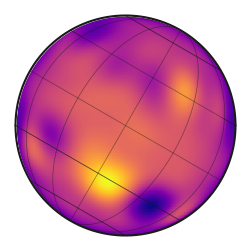

In [126]:
map.show()

In [10]:
sys.show(t[::100])

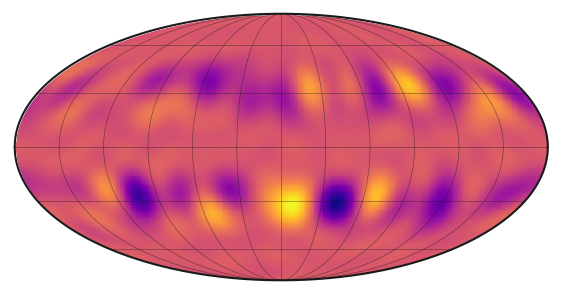

In [127]:
map.show(projection='moll')

In [128]:
theta = (360 * t / params["star.prot"]['truth']) % 360
xo, yo, zo = sys.position(t)
xo = xo.eval()[1]
yo = yo.eval()[1]
zo = zo.eval()[1]
A = map.design_matrix(
    theta=theta, xo=xo, yo=yo, zo=zo, ro=params["planet.r"]['truth']
).eval()

In [129]:
rng = np.random.default_rng(9878997)
flux_true = A @ y_true
sigma_flux = 1e-4*np.ones_like(flux_true)
flux_obs = flux_true + sigma_flux*rng.normal(size=len(t))

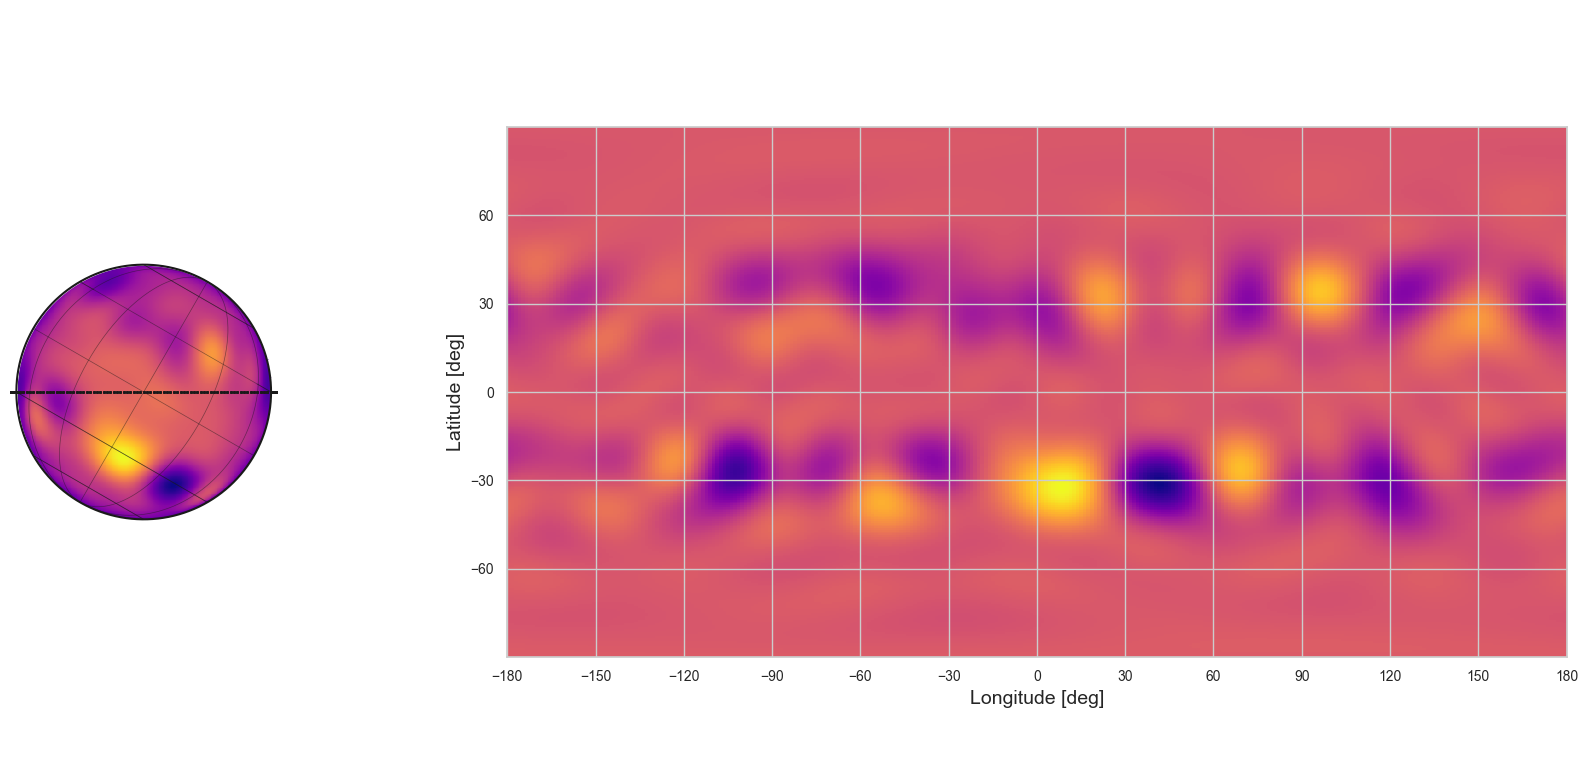

In [130]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
ax[0].plot(xo[idx], yo[idx], "k.", ms=1);
ax[0].set_aspect(1)
ax[0].axis("off")
map[:, :] = y_true
map.show(ax=ax[0])
ax[0].set_ylim(-3, 3)
idx = (zo > 0) & (xo ** 2 + yo ** 2 < 1)
lat = 180 / np.pi * np.arcsin(yo[idx])
lon = 180 / np.pi * np.arcsin(xo[idx] / np.sqrt(1 - yo[idx] ** 2)) - theta[idx]
lon = (lon + 180) % 360 - 180
mask = np.append(np.array(lon[1:] > lon[:-1], dtype=float), 0)
mask[mask == 1] = np.nan
map.show(ax=ax[1], projection="rect")
ax[1].plot(lon, lat + mask, "k-");
plt.tight_layout()
# plt.savefig("figures/experiment-1-true-map.pdf", bbox_inches="tight", dpi=300)

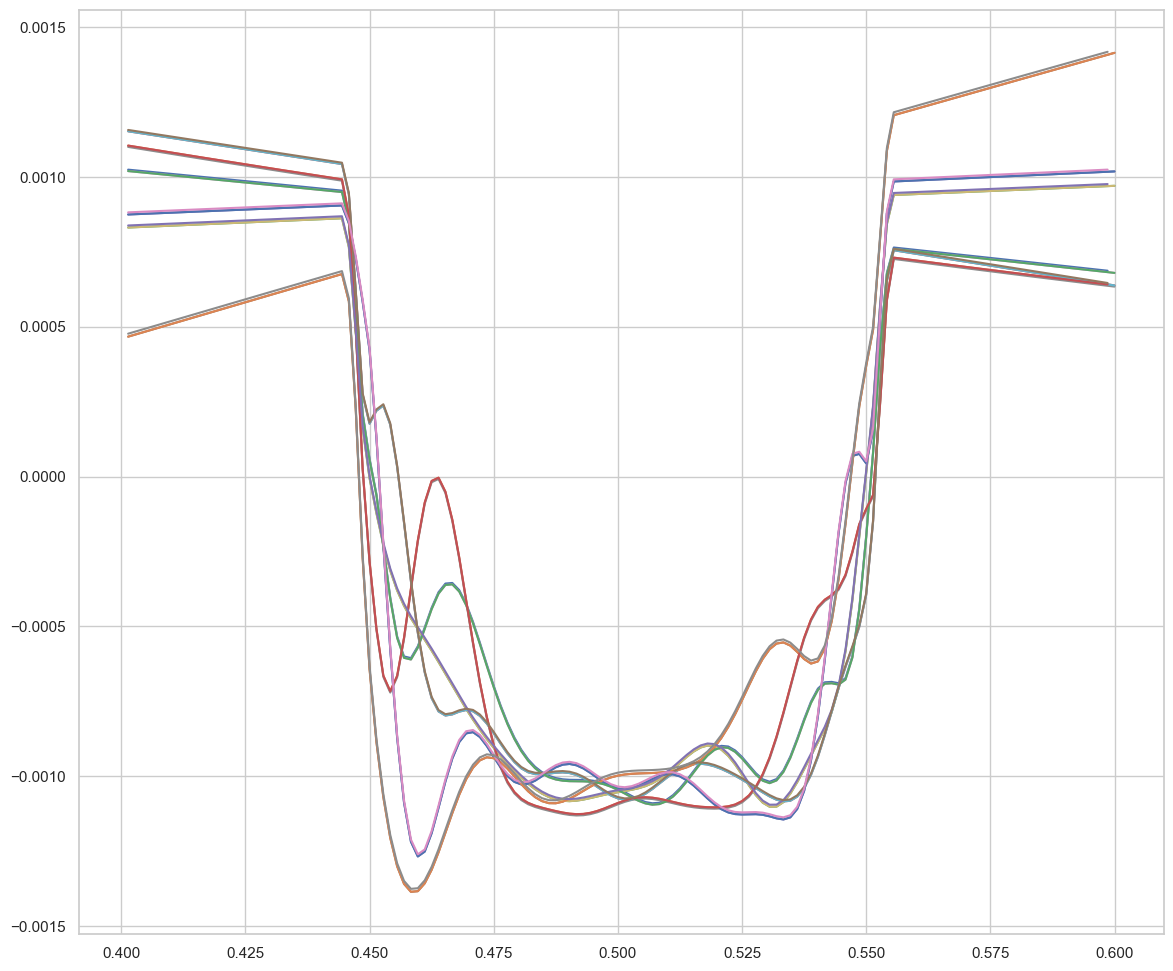

In [131]:
ntransits = int(np.ceil(t[-1] / planet.porb.eval()))
fig, ax = plt.subplots(1, 1)
for n in range(ntransits):
    idx = (t > planet.t0.eval()+n*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+n*planet.porb.eval()+0.1)
    plt.plot(t[idx] % planet.porb.eval(), flux_true[idx] - np.mean(flux_true[idx]))

In [132]:
t_, flux_, sigma_flux_ = bin_out_of_transit(t, flux_obs, sigma_flux, params, binsize=100)

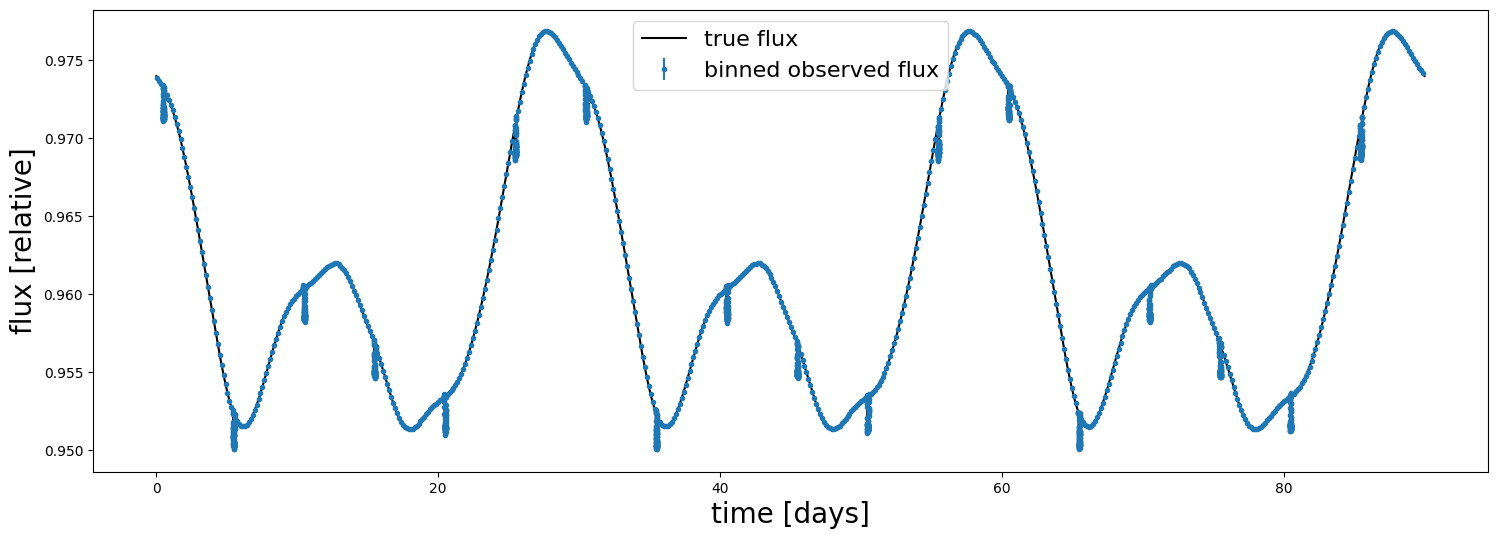

In [14]:
plt.figure(figsize=(18,6))
plt.plot(t, flux_true, color='k', label='true flux')
plt.errorbar(t_, flux_, yerr=sigma_flux_, fmt='.', color='C0', label='binned observed flux')
plt.ylabel("flux [relative]", fontsize=20)
plt.xlabel("time [days]", fontsize=20)
plt.legend(fontsize=16);
plt.savefig("figures/experiment-1-lc.pdf", bbox_inches="tight", dpi=300)
# plt.xlim(0,20)

(15.0, 16.0)

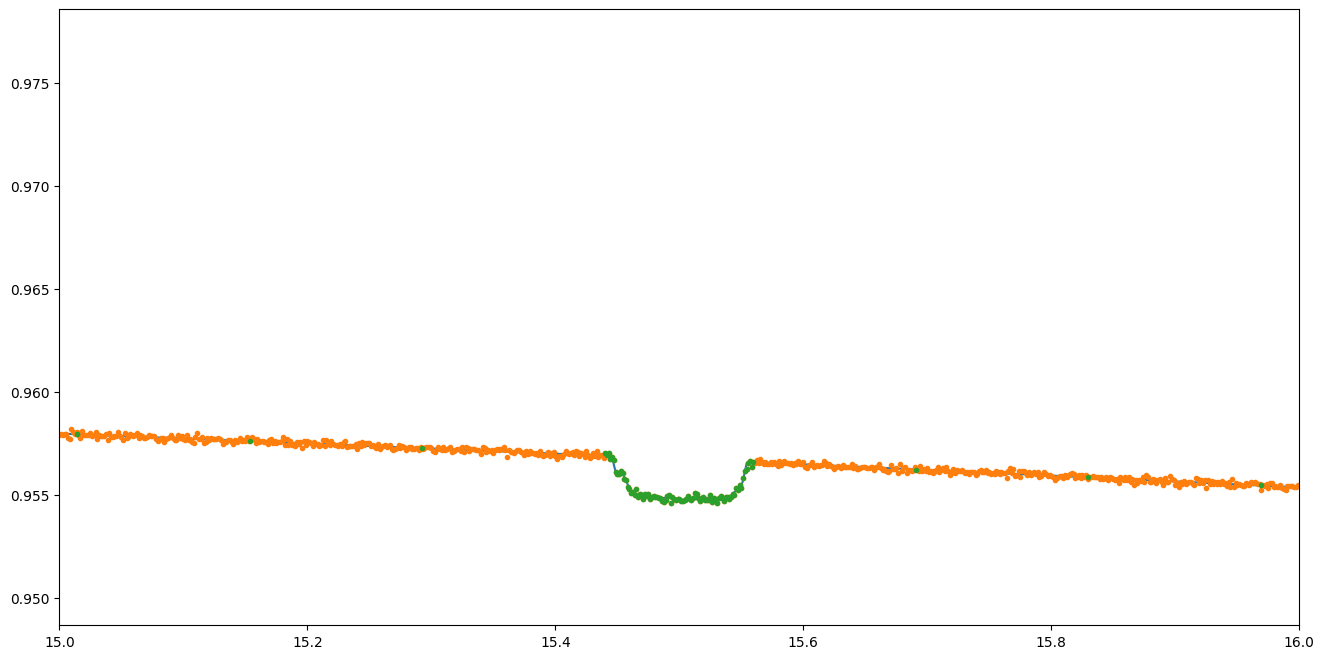

In [80]:
plt.figure(figsize=(16,8))
plt.plot(t, flux_true)
plt.plot(t, flux_obs, '.')
plt.plot(t_, flux_, '.')
plt.xlim(15, 16)

In [81]:
np.sum(np.isnan(flux_))

0

In [133]:
# Set some free params & get the model
p = dict(params)

# p['planet.porb']['free'] = True
# p['planet.t0']['free'] = True
# p['planet.r']['free'] = True
# p['planet.inc']['free'] = True
# p['planet.ecc']['free'] = True

# p['star.u1']['free'] = True
# p['star.u2']['free'] = True

p['gp.c']['free'] = True
p['gp.mu']['free'] = True
p['gp.sigma']['free'] = True
p['gp.r']['free'] = True
p['gp.n']['free'] = True

# p['star.prot']['free'] = True
# p['star.obl']['free'] = True
# p['star.inc']['free'] = True

free = [x for x in p.keys() if p[x].get("free", False)]
model = gp_model(t_, flux_, sigma_flux_, p)

In [83]:
t_.shape

(2180,)

In [134]:
best_params = {}
# best_params['star.inc'] = params['star.inc']['truth']
# best_params['star.obl'] = params['star.obl']['truth']
# best_params['star.m'] = params['star.m']['truth']
best_params['gp.mu'] = params['gp.mu']['truth']
best_params['gp.sigma'] = params['gp.sigma']['truth']
best_params['gp.c'] = params['gp.c']['truth']
best_params['gp.n'] = params['gp.n']['truth']
best_params['gp.r'] = params['gp.r']['truth']
# best_params['star.prot'] = params['star.prot']['truth']
# best_params['planet.porb'] = params['planet.porb']['truth']
# best_params['planet.t0'] = params['planet.t0']['truth']
# best_params['planet.ecc'] = params['planet.ecc']['truth']
# best_params['planet.r'] = params['planet.r']['truth']
# best_params['star.u1'] = params['star.u1']['truth']
# best_params['star.u2'] = params['star.u2']['truth']
# best_params['planet.inc'] = params['planet.inc']['truth']

In [135]:
with model:
    map_soln = pmx.optimize(start=best_params)
    for x in free:
        print(f"{x}: {map_soln[x]} {[params[x]['truth']]}")

optimizing logp for variables: [gp.n, gp.r, gp.c, gp.sigma, gp.mu]



gp.mu: 36.73738063645725 [30.0]
gp.sigma: 9.931320138319569 [5.0]
gp.r: 19.70522130685926 [10]
gp.c: 0.5859420612540963 [0.5]
gp.n: 4.732605355395172 [3]


message: Desired error not necessarily achieved due to precision loss.
logp: -72280.35402727616 -> -72216.767780247


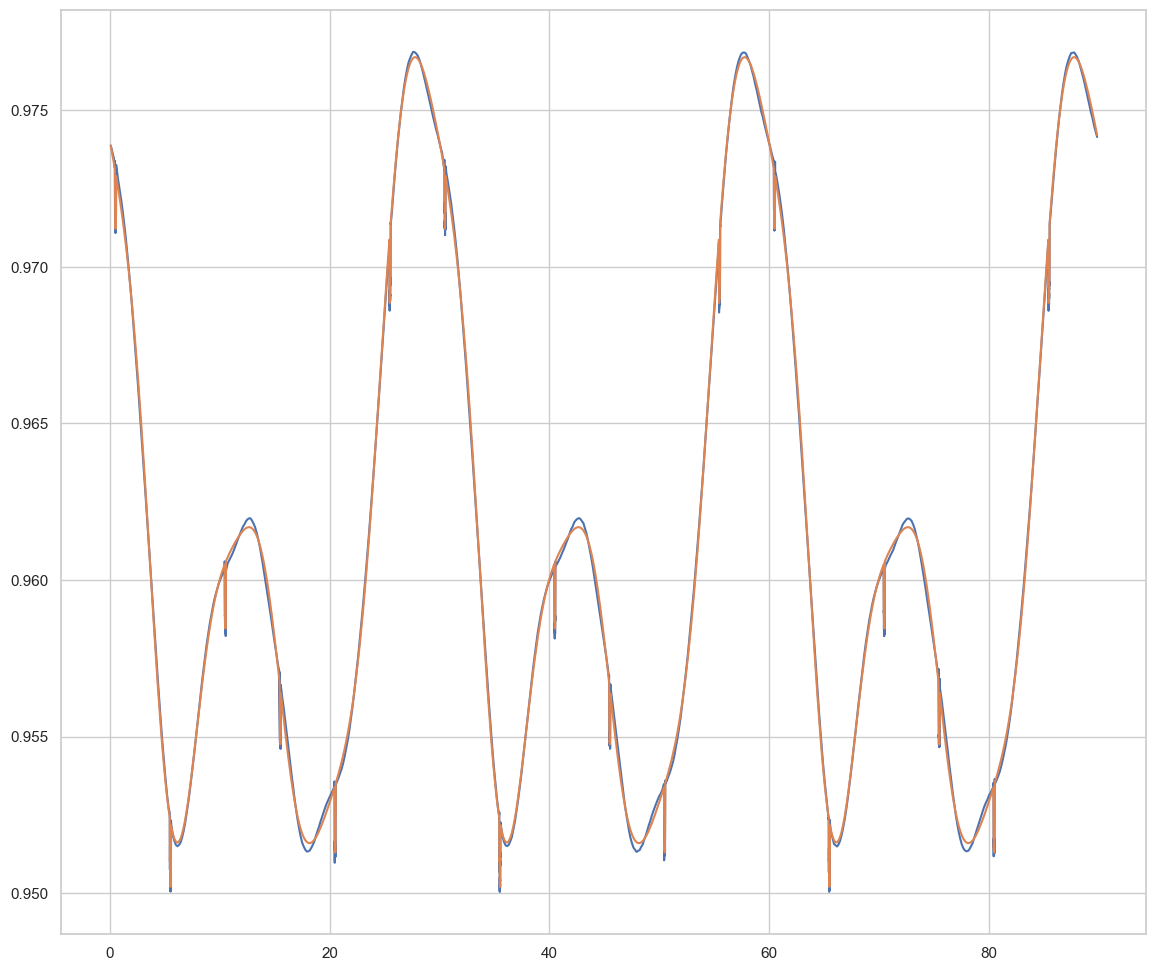

In [136]:
plt.plot(t_, flux_)
plt.plot(t_, map_soln['flux_model'])
# plt.xlim(34,36)
# plt.ylim(0.950,0.955)

In [137]:
map_opt = starry.Map(6,2)
map_opt[:,:] = map_soln['max_map']

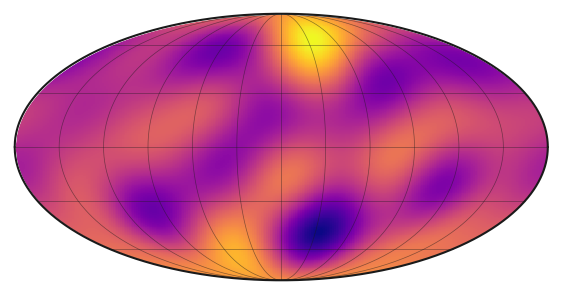

In [138]:
map_opt.show(projection='moll')

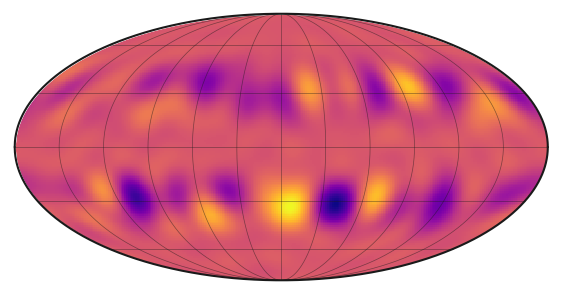

In [139]:
sp.visualize(y_true)

In [140]:
with model:
    trace = pmx.sample(
        tune=1000,
        draws=1000,
        start=map_soln,
        chains=1,
        cores=1,
        target_accept=0.9,
        return_inferencedata=False,
    )

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
2025-03-30 21:32:56 - pymc3 - INFO: The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Sequential sampling (1 chains in 1 job)
2025-03-30 21:32:56 - pymc3 - INFO: Sequential sampling (1 chains in 1 job)
NUTS: [gp.n, gp.r, gp.c, gp.sigma, gp.mu]
2025-03-30 21:32:56 - pymc3 - INFO: NUTS: [gp.n, gp.r, gp.c, gp.sigma, gp.mu]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 266 seconds.
2025-03-30 21:37:24 - pymc3 - INFO: Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 266 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
2025-03-30 21:37:26 - pymc3 - INFO: Only one chain was sampled, this makes it impossible to run some convergence checks


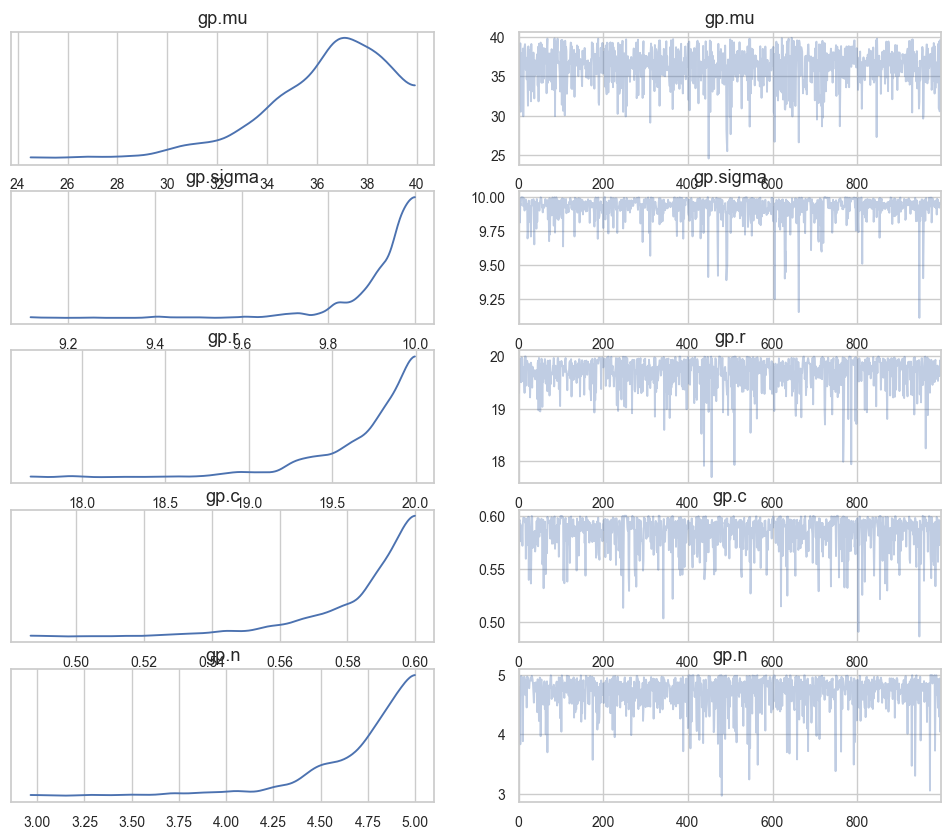

In [141]:
with model:
    az.plot_trace(trace, var_names=free)

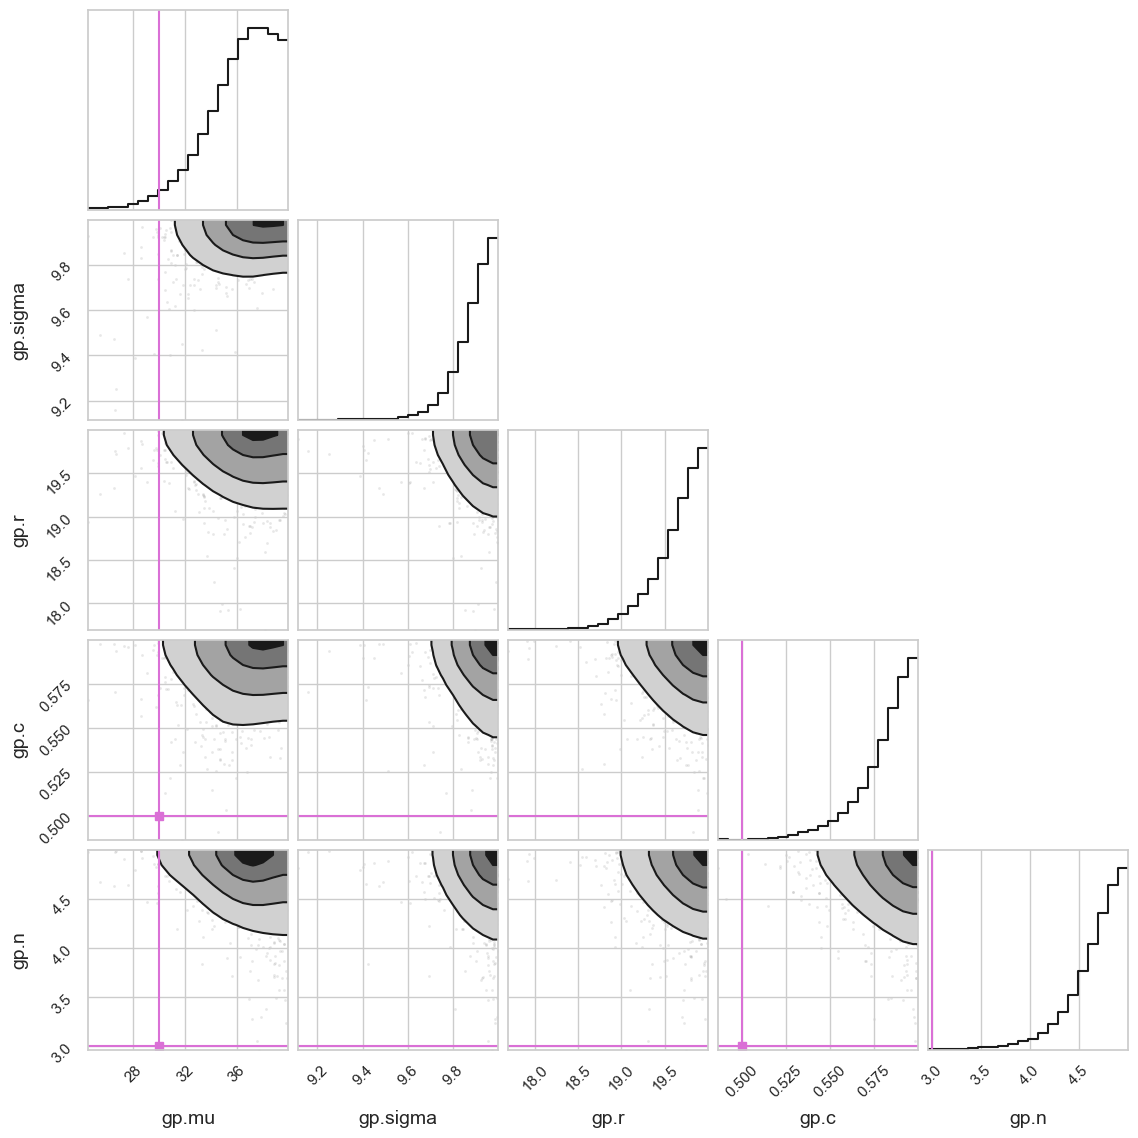

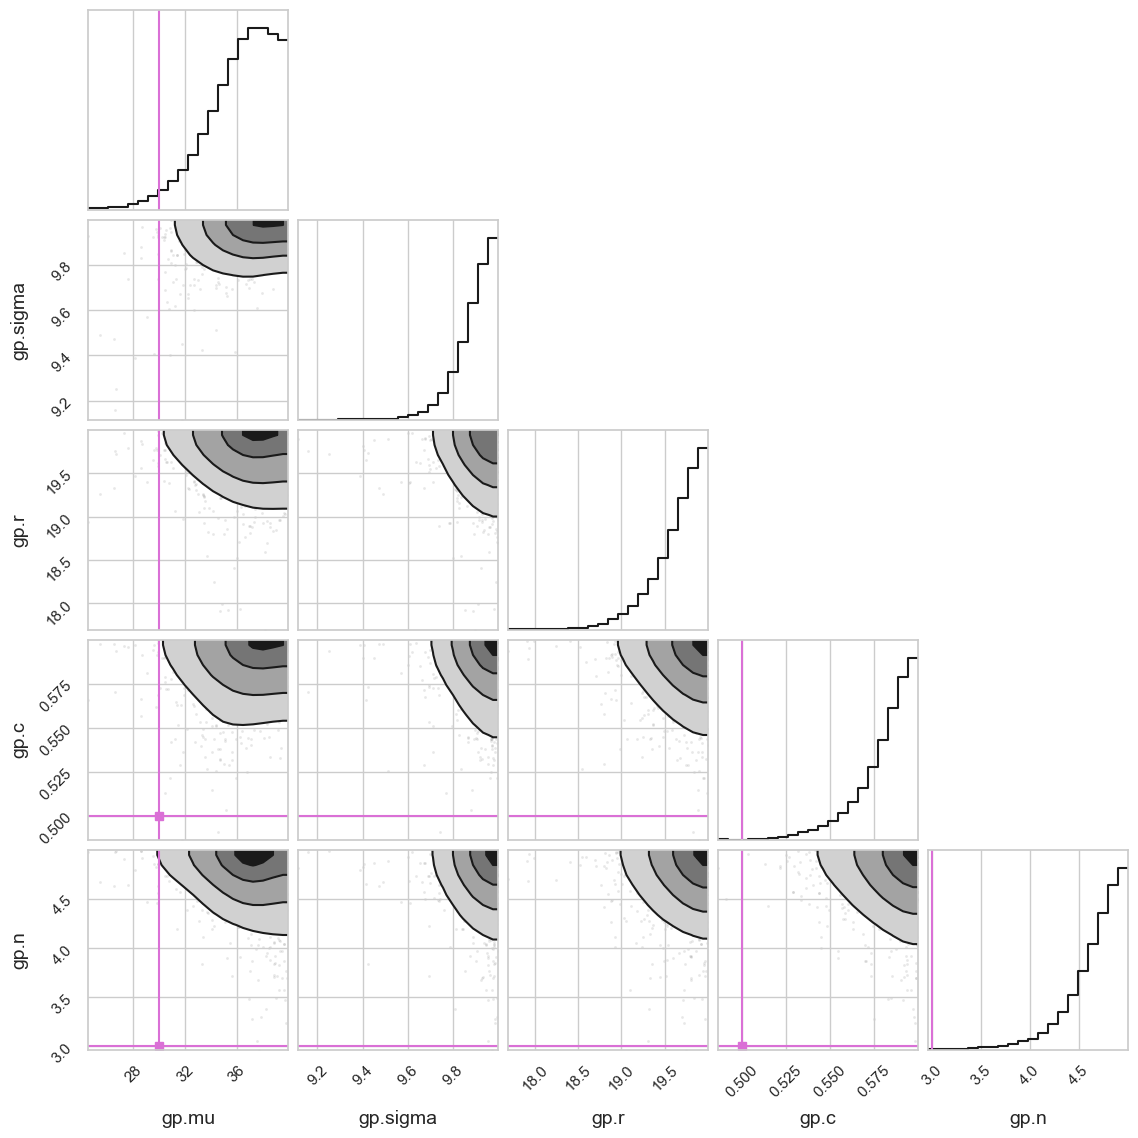

In [142]:
samples = pm.trace_to_dataframe(trace,varnames=free)
corner(np.array(samples), labels=free,
        truths=[params[x]['truth'] for x in free], 
        color='k', 
        truth_color='orchid',
        plot_datapoints=True,
        plot_density=False,
        fill_contours=True,
        smooth=2.,
        smooth1d=2.,
        hist_kwargs=dict(alpha=1))

In [144]:
az.to_netcdf(trace,'/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-ylm6.nc')

2025-03-30 21:38:20 - arviz.data.io_pymc3_3x - ERROR: Got error No model on context stack. trying to find log_likelihood in translation.


'/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-ylm6.nc'

In [145]:
samples_fromfile = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-ylm6.nc')

In [146]:
free

['gp.mu', 'gp.sigma', 'gp.r', 'gp.c', 'gp.n']

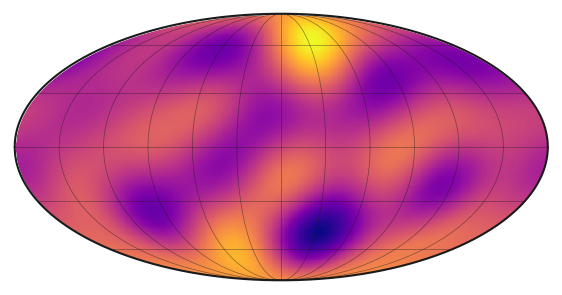

In [147]:
map_opt = starry.Map(6,2)
map_opt[:,:] = np.mean(samples_fromfile.posterior[f'max_map'][0].values, axis=0)
map_opt.show(projection='moll')

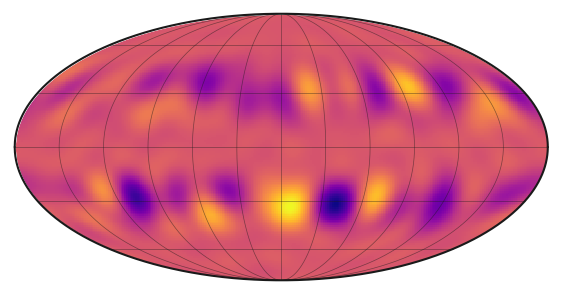

In [148]:
sp.visualize(y_true)

Corner plots generated successfully!


<Figure size 1200x1000 with 0 Axes>

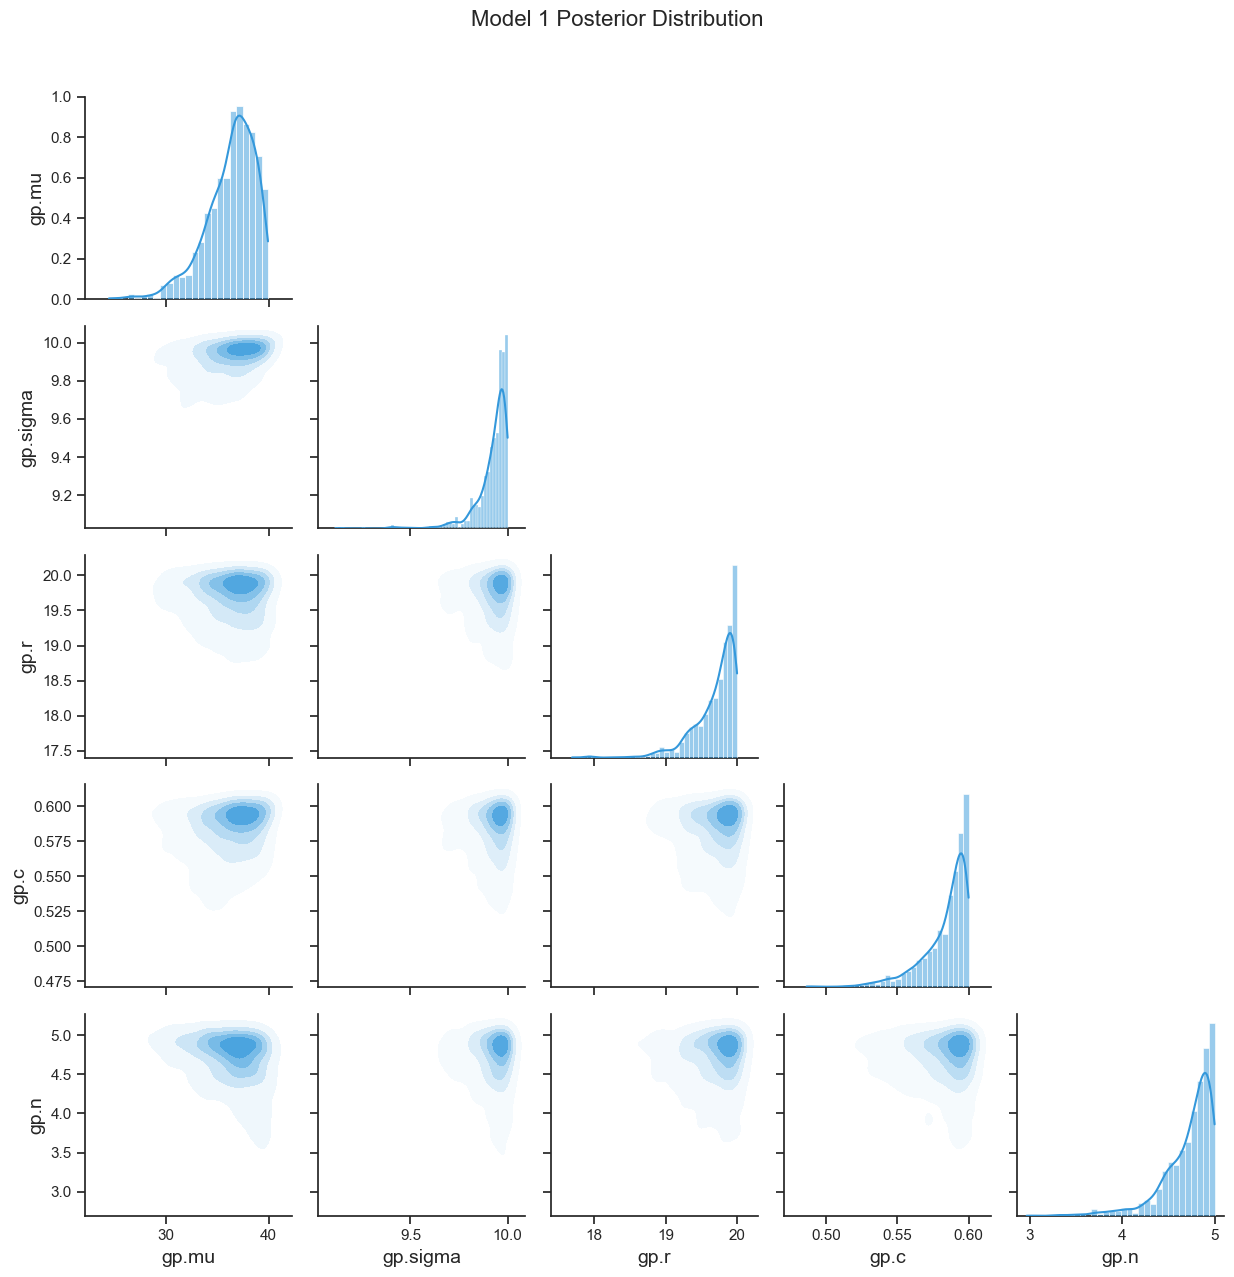

<Figure size 1200x1000 with 0 Axes>

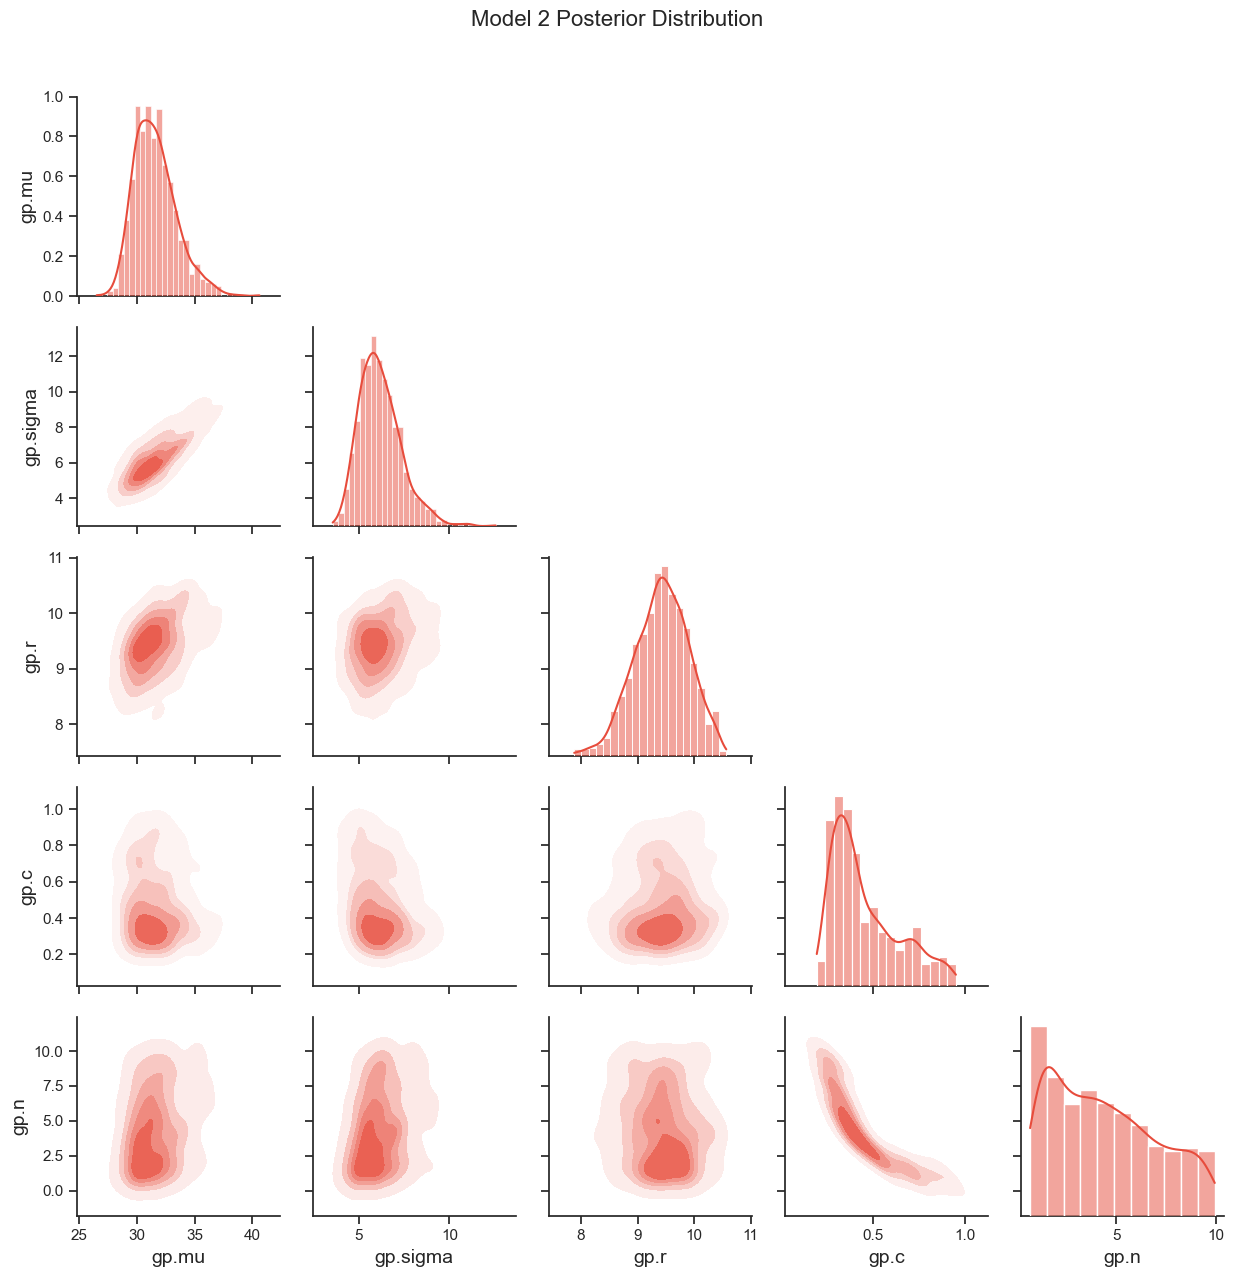

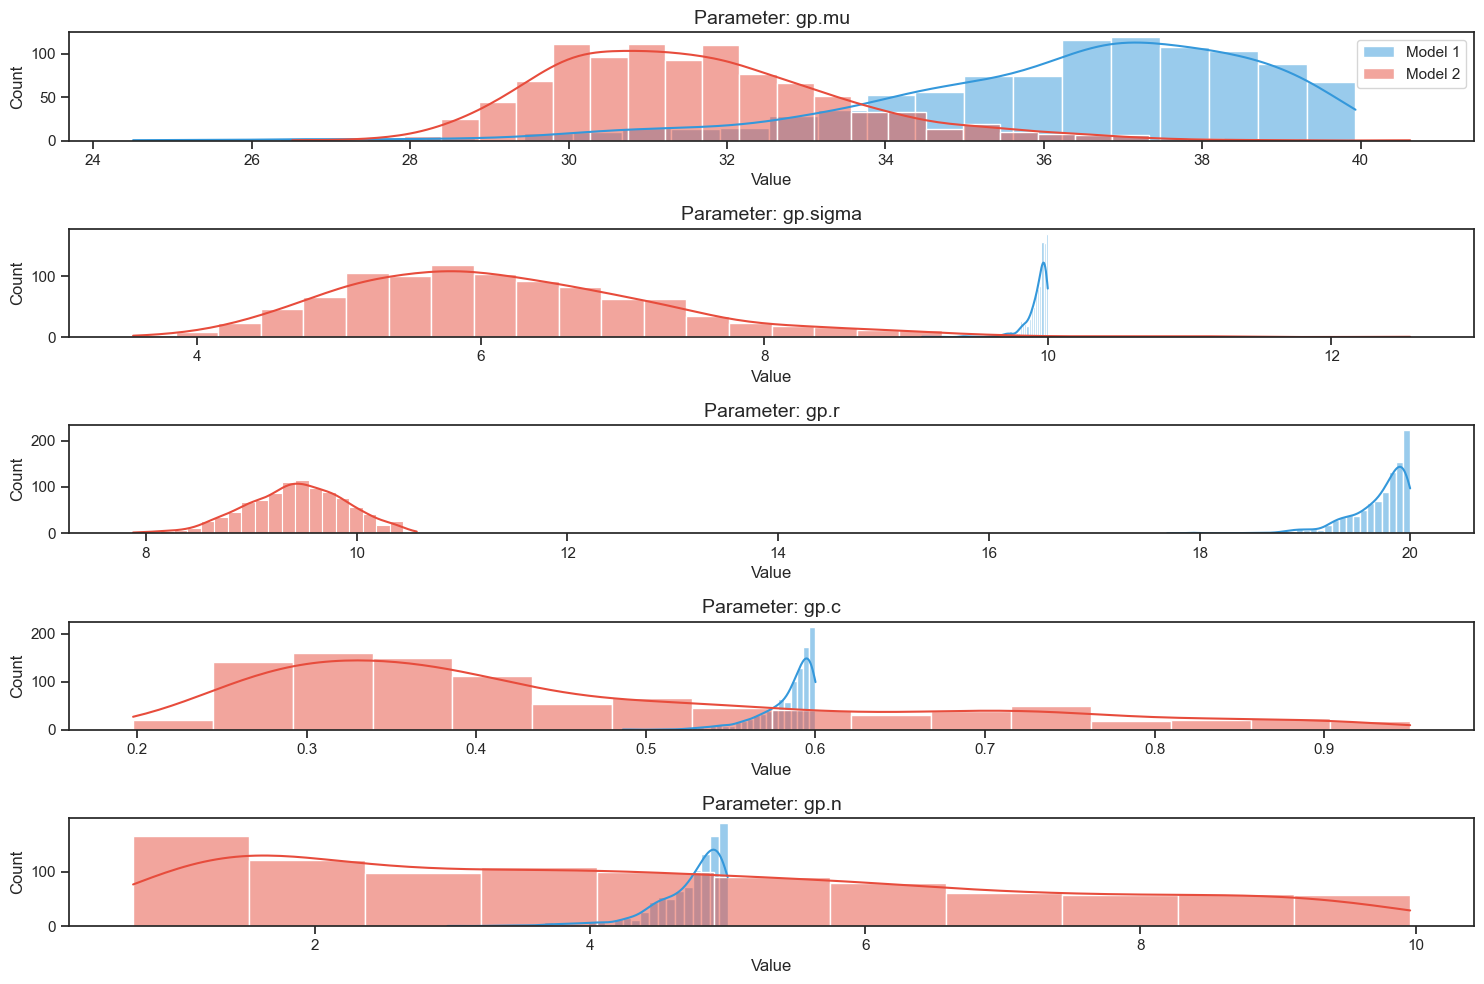

<Figure size 1200x1000 with 0 Axes>

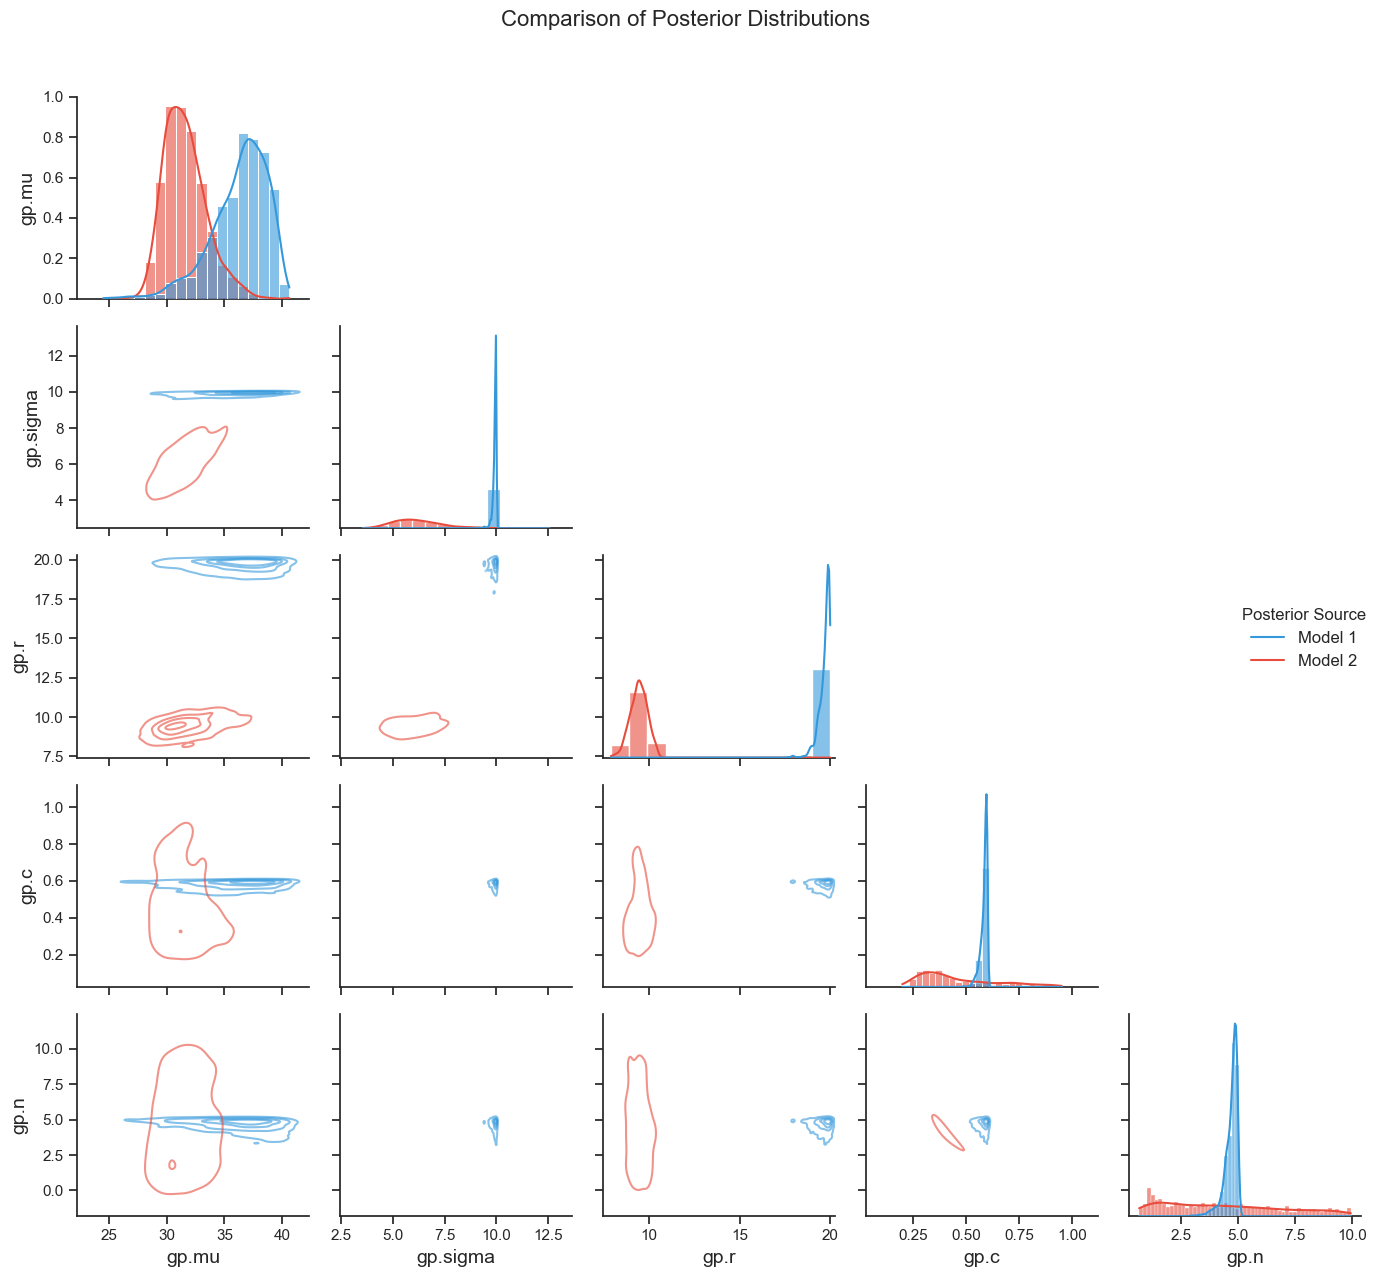

In [149]:
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Set the style
sns.set(style='ticks')

# Load the posterior samples from both files
samples_file1 = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-ylm6.nc')
samples_file2 = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-1-all-2.nc')

# Parameters of interest
params = ['gp.mu', 'gp.sigma', 'gp.r', 'gp.c', 'gp.n']

# Create custom nice-looking colormaps
cmap1 = LinearSegmentedColormap.from_list("custom_cmap1", ["#ffffff", "#3498db"])
cmap2 = LinearSegmentedColormap.from_list("custom_cmap2", ["#ffffff", "#e74c3c"])

# Function to extract posterior samples into a DataFrame
def extract_posterior_samples(inference_data, params):
    df = pd.DataFrame()
    
    for param in params:
        if param in inference_data.posterior.variables:
            # Extract the parameter samples and flatten them
            param_samples = inference_data.posterior[param].values.flatten()
            df[param] = param_samples
    
    return df

# Extract samples into DataFrames
df1 = extract_posterior_samples(samples_file1, params)
df2 = extract_posterior_samples(samples_file2, params)

# Make sure we have data for both models
if df1.empty or df2.empty:
    raise ValueError("Could not extract parameters from one or both of the posterior files")

# Plot separate corner plots for each model
# First model
plt.figure(figsize=(12, 10))
g1 = sns.PairGrid(df1[params], diag_sharey=False)

# Map the histograms to the diagonal
g1.map_diag(sns.histplot, kde=True, color='#3498db')  # Blue

# Map the 2D contour plots to the lower triangle
g1.map_lower(sns.kdeplot, cmap=cmap1, levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g1.map_upper(remove_upper)

# Adjust labels
for i, var in enumerate(params):
    g1.axes[-1, i].set_xlabel(var, fontsize=14)
    g1.axes[i, 0].set_ylabel(var, fontsize=14)

plt.suptitle('Model 1 Posterior Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("model1_corner_plot.png", dpi=300)

# Second model
plt.figure(figsize=(12, 10))
g2 = sns.PairGrid(df2[params], diag_sharey=False)

# Map the histograms to the diagonal
g2.map_diag(sns.histplot, kde=True, color='#e74c3c')  # Red

# Map the 2D contour plots to the lower triangle
g2.map_lower(sns.kdeplot, cmap=cmap2, levels=6, fill=True)

# Remove the scatter plots and empty axes in the upper triangle
g2.map_upper(remove_upper)

# Adjust labels
for i, var in enumerate(params):
    g2.axes[-1, i].set_xlabel(var, fontsize=14)
    g2.axes[i, 0].set_ylabel(var, fontsize=14)

plt.suptitle('Model 2 Posterior Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("model2_corner_plot.png", dpi=300)

# Now create a combined visualization showing both models on same plots
# Prepare figure for overlaid marginal distributions
plt.figure(figsize=(15, 10))

# For each parameter, create an overlaid density plot
for i, param in enumerate(params):
    if param in df1.columns and param in df2.columns:
        plt.subplot(len(params), 1, i+1)
        
        # Plot histograms with KDE for both models
        sns.histplot(df1[param], kde=True, color='#3498db', alpha=0.5, label='Model 1')
        sns.histplot(df2[param], kde=True, color='#e74c3c', alpha=0.5, label='Model 2')
        
        plt.title(f'Parameter: {param}', fontsize=14)
        plt.xlabel('Value')
        
        # Only add legend to the first plot
        if i == 0:
            plt.legend()

plt.tight_layout()
plt.savefig("overlaid_marginals.png", dpi=300)

# Create an improved combined corner plot with both distributions
# Make sure we have equal number of samples for fair comparison
min_samples = min(len(df1), len(df2))
df1_sampled = df1.sample(min_samples, random_state=42) if len(df1) > min_samples else df1
df2_sampled = df2.sample(min_samples, random_state=42) if len(df2) > min_samples else df2

# Add model identifier column
df1_sampled['model'] = 'Model 1'
df2_sampled['model'] = 'Model 2'

# Combine the dataframes
combined_df = pd.concat([df1_sampled, df2_sampled])

# Create the combined corner plot
plt.figure(figsize=(12, 10))

# Create PairGrid
g = sns.PairGrid(combined_df, hue='model', diag_sharey=False, 
                 vars=params, palette={'Model 1': '#3498db', 'Model 2': '#e74c3c'})

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, alpha=0.6)

# Map the 2D KDE plots to the lower triangle
g.map_lower(sns.kdeplot, levels=5, alpha=0.6)

# Remove the upper triangle
g.map_upper(remove_upper)

# Add a legend
g.add_legend(title='Posterior Source', fontsize=12)

# Adjust labels
for i, var in enumerate(params):
    g.axes[-1, i].set_xlabel(var, fontsize=14)
    g.axes[i, 0].set_ylabel(var, fontsize=14)

plt.suptitle('Comparison of Posterior Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("combined_corner_plot.png", dpi=300)

print("Corner plots generated successfully!")

In [111]:
custom_labels = {
    'gp.mu': r'$\mu_\phi$',
    'gp.sigma': r'$\sigma^2_\phi$',
    'gp.r': r'$\mathbb{r}$',
    'gp.c': r'$\mathbb{c}$',
    'gp.n': r'$\mathbb{n}$'
}

Final corner plot created with LaTeX labels!


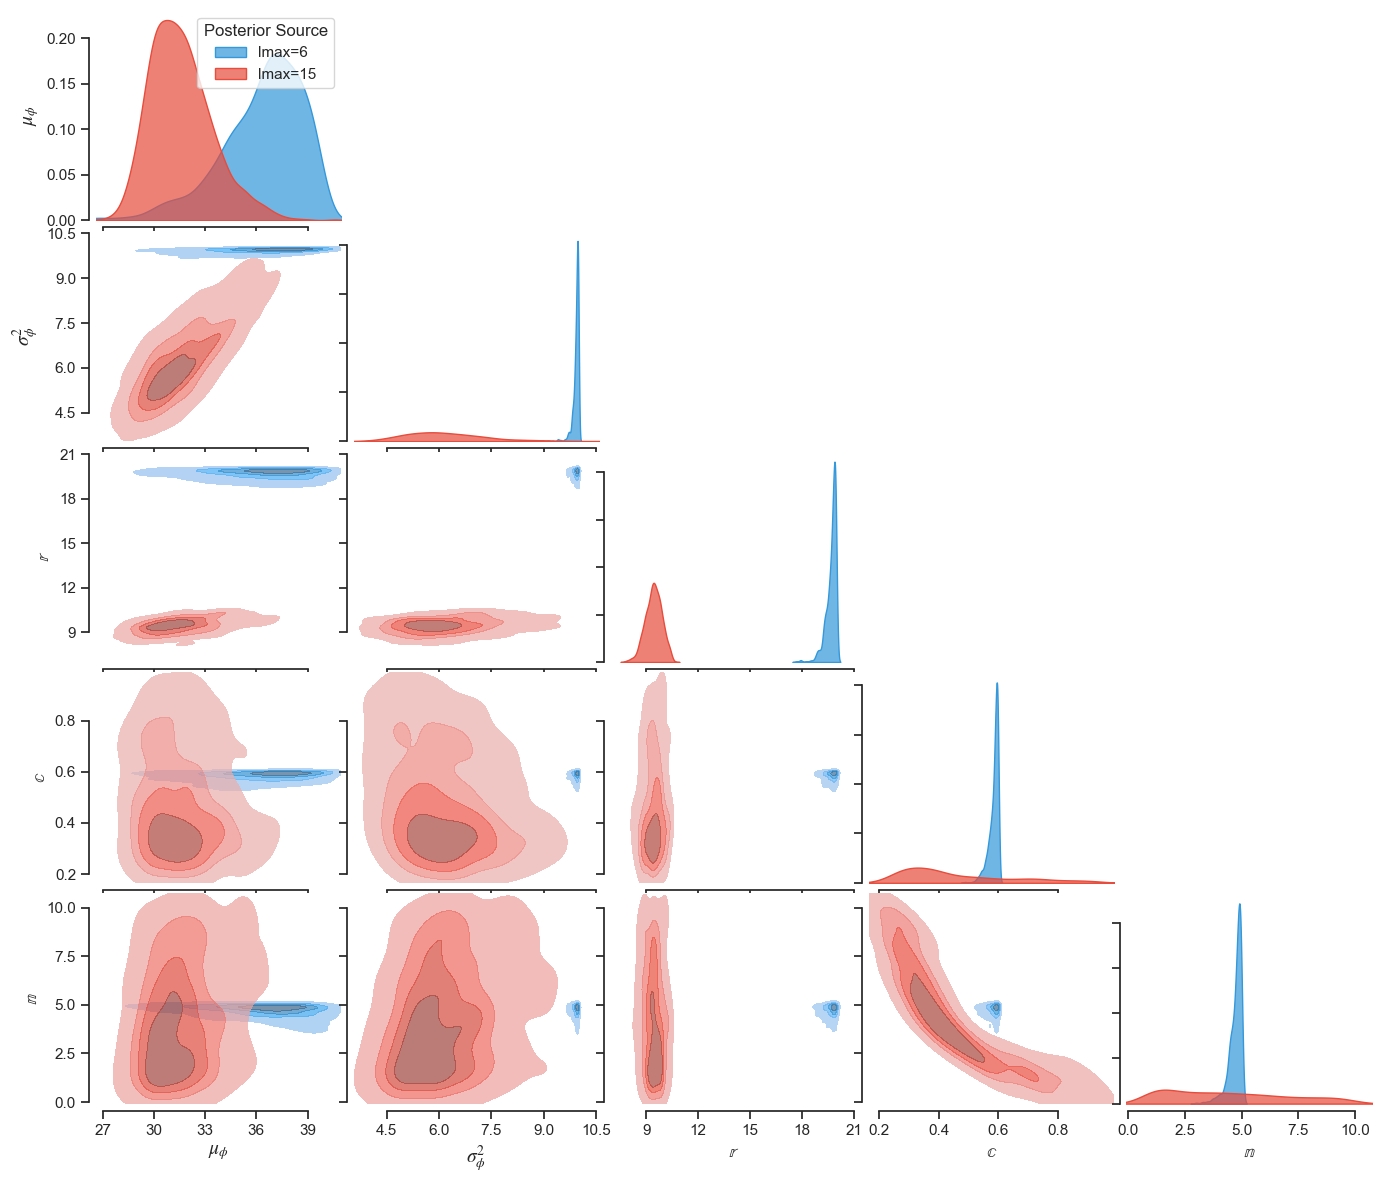

In [150]:
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Set a clean style without grid
sns.set_style("ticks")
plt.rcParams.update({'font.size': 12})

# Load the posterior samples from both files
samples_file1 = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-ylm6.nc')
samples_file2 = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-1-all-2.nc')

# Parameters of interest
params = ['gp.mu', 'gp.sigma', 'gp.r', 'gp.c', 'gp.n']

# Custom LaTeX labels as requested
custom_labels = {
    'gp.mu': r'$\mu_\phi$',
    'gp.sigma': r'$\sigma^2_\phi$',
    'gp.r': r'$\mathbb{r}$',
    'gp.c': r'$\mathbb{c}$',
    'gp.n': r'$\mathbb{n}$'
}

# Consistent naming matching your example
model1_name = "lmax=6"   # Blue in your image
model2_name = "lmax=15"  # Red in your image

# Function to extract posterior samples into a DataFrame
def extract_posterior_samples(inference_data, params):
    df = pd.DataFrame()
    
    for param in params:
        if param in inference_data.posterior.variables:
            # Extract the parameter samples and flatten them
            param_samples = inference_data.posterior[param].values.flatten()
            df[param] = param_samples
    
    return df

# Extract samples into DataFrames
df1 = extract_posterior_samples(samples_file1, params)
df2 = extract_posterior_samples(samples_file2, params)

# Function to determine optimal plot limits for each parameter
def get_optimal_limits(df1, df2, param, padding=0.1):
    combined = np.concatenate([df1[param].values, df2[param].values])
    
    # Calculate robust min/max with percentiles to avoid outliers
    data_min = np.percentile(combined, 0.5)
    data_max = np.percentile(combined, 99.5)
    
    # Calculate range and add padding
    data_range = data_max - data_min
    
    # Return limits with padding
    return (data_min - padding * data_range, data_max + padding * data_range)

# Create figure and axes
fig, axes = plt.subplots(len(params), len(params), figsize=(14, 12))

# Turn off upper triangle
for i in range(len(params)):
    for j in range(len(params)):
        if j > i:
            axes[i, j].axis('off')

# Colors matching your example
color1 = '#3498db'  # Blue for lmax=6
color2 = '#e74c3c'  # Red for lmax=15

# Plot each parameter
for i, param_y in enumerate(params):
    for j, param_x in enumerate(params):
        ax = axes[i, j]
        
        # Skip upper triangle
        if j > i:
            continue
            
        # For diagonal plots (marginal distributions)
        if i == j:
            # Get optimal limits
            x_min, x_max = get_optimal_limits(df1, df2, param_x)
            
            # Plot KDE for both models
            sns.kdeplot(df1[param_x], ax=ax, color=color1, fill=True, alpha=0.7, 
                       label=model1_name, bw_adjust=1.0)
            sns.kdeplot(df2[param_x], ax=ax, color=color2, fill=True, alpha=0.7, 
                       label=model2_name, bw_adjust=1.0)
            
            # Set limits
            ax.set_xlim(x_min, x_max)
            
            # Only add legend to first plot
            if i == 0 and j == 0:
                ax.legend(title="Posterior Source", loc='upper right')
                
        # For off-diagonal plots (joint distributions)
        else:
            # Get optimal limits for both axes
            x_min, x_max = get_optimal_limits(df1, df2, param_x)
            y_min, y_max = get_optimal_limits(df1, df2, param_y)
            
            # Plot contours for both models
            sns.kdeplot(x=df1[param_x], y=df1[param_y], ax=ax, 
                       levels=5, color=color1, fill=True, alpha=0.7)
            sns.kdeplot(x=df2[param_x], y=df2[param_y], ax=ax, 
                       levels=5, color=color2, fill=True, alpha=0.7)
            
            # Set limits
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
        
        # Remove grid
        ax.grid(False)
        
        # Clean up ticks
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        
        # Use custom labels
        if i == len(params) - 1:
            ax.set_xlabel(custom_labels[param_x], fontsize=14)
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])
            
        if j == 0:
            ax.set_ylabel(custom_labels[param_y], fontsize=14)
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])

        # Add tick marks with less padding
        sns.despine(ax=ax, offset=5, trim=True)

# No title as requested

# Adjust spacing
plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Save the plot in high resolution
# plt.savefig("final_corner_plot.png", dpi=300, bbox_inches='tight')
# plt.savefig("final_corner_plot.pdf", bbox_inches='tight')

print("Final corner plot created with LaTeX labels!")

Improved violin plot created successfully!


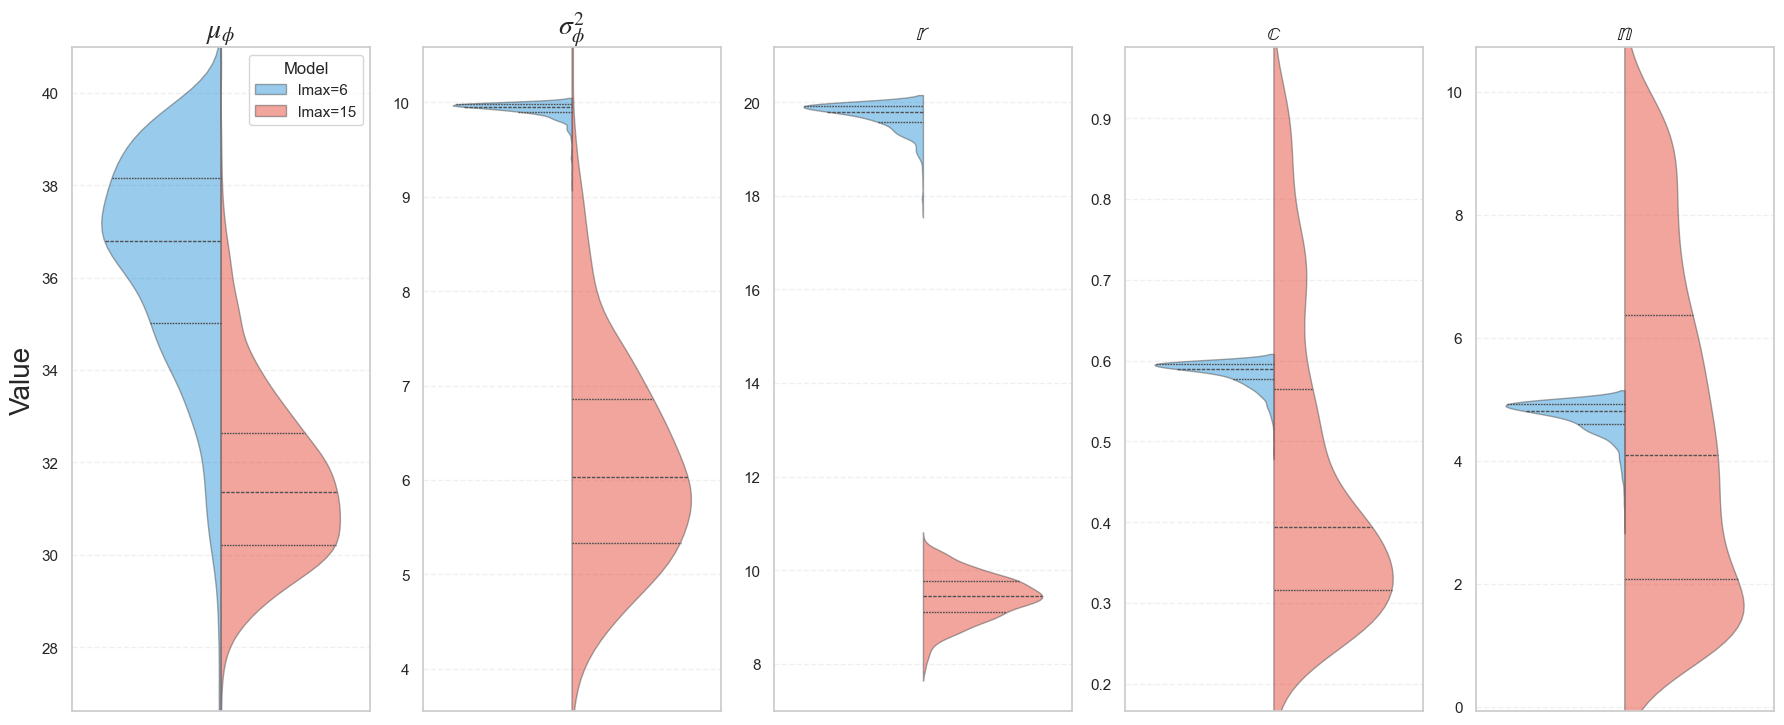

In [156]:
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Set a clean style
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# Load the posterior samples from both files
samples_file1 = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-ylm6.nc')
samples_file2 = az.from_netcdf('/Users/sabina/Desktop/GitHub/archived-data/SSP-experiment-1-all-2.nc')

# Parameters of interest
params = ['gp.mu', 'gp.sigma', 'gp.r', 'gp.c', 'gp.n']

# Custom LaTeX labels as requested
custom_labels = {
    'gp.mu': r'$\mu_\phi$',
    'gp.sigma': r'$\sigma^2_\phi$',
    'gp.r': r'$\mathbb{r}$',
    'gp.c': r'$\mathbb{c}$',
    'gp.n': r'$\mathbb{n}$'
}

# Consistent naming matching your example
model1_name = "lmax=6"   # Blue in your image
model2_name = "lmax=15"  # Red in your image

# Colors matching your example
color1 = '#3498db'  # Blue for lmax=6
color2 = '#e74c3c'  # Red for lmax=15

# Function to extract posterior samples into a DataFrame
def extract_posterior_samples(inference_data, params):
    df = pd.DataFrame()
    
    for param in params:
        if param in inference_data.posterior.variables:
            # Extract the parameter samples and flatten them
            param_samples = inference_data.posterior[param].values.flatten()
            df[param] = param_samples
    
    return df

# Extract samples into DataFrames
df1 = extract_posterior_samples(samples_file1, params)
df2 = extract_posterior_samples(samples_file2, params)

# Create a long-form DataFrame suitable for seaborn
violin_data = []

for param in params:
    # Add scaled samples for model 1
    if param in df1.columns:
        for value in df1[param]:
            violin_data.append({
                'Parameter': custom_labels[param],
                'Value': value,
                'Model': model1_name
            })
    
    # Add scaled samples for model 2
    if param in df2.columns:
        for value in df2[param]:
            violin_data.append({
                'Parameter': custom_labels[param],
                'Value': value,
                'Model': model2_name
            })

# Convert to DataFrame
violin_df = pd.DataFrame(violin_data)

# Create separate violin plots for each parameter to handle different scales better
fig, axes = plt.subplots(1, len(params), figsize=(18, 8), sharey=False)

for i, param in enumerate(params):
    param_label = custom_labels[param]
    
    # Filter data for this parameter
    param_data = violin_df[violin_df['Parameter'] == param_label]
    
    # Create violin plot for this parameter
    sns.violinplot(
        data=param_data,
        x='Parameter',
        y='Value',
        hue='Model',
        ax=axes[i],
        palette={model1_name: color1, model2_name: color2},
        split=True,
        inner='quartile',
        linewidth=1,
        saturation=1.0,
        alpha=0.5
    )
    
    # Remove unnecessary elements
    if i > 0:
        axes[i].set_ylabel('')
    else:
        axes[i].set_ylabel('Value', fontsize=20)
    
    # Remove the x-label since it's redundant (shown at the bottom)
    axes[i].set_xlabel('')
    
    # Remove legend from all but the first plot
    if i > 0:
        if axes[i].legend_:
            axes[i].legend_.remove()
    else:
        axes[i].legend(title='Model', loc='upper right')
    
    # Set title as the parameter
    axes[i].set_title(param_label, fontsize=20)
    
    # Remove grid lines
    axes[i].grid(False, axis='x')
    axes[i].grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Adjust y limits for better visibility
    model1_data = param_data[param_data['Model'] == model1_name]['Value']
    model2_data = param_data[param_data['Model'] == model2_name]['Value']
    
    if not model1_data.empty and not model2_data.empty:
        all_data = pd.concat([model1_data, model2_data])
        y_min = np.percentile(all_data, 0.5)
        y_max = np.percentile(all_data, 99.5)
        
        # Add padding to y range
        y_range = y_max - y_min
        y_min -= 0.1 * y_range
        y_max += 0.1 * y_range
        
        axes[i].set_ylim(y_min, y_max)
    
    # Remove the x-tick label since it's redundant
    axes[i].set_xticklabels([], fontsize=16)

# Add a common x-label at the bottom
# fig.text(0.5, 0.01, 'Parameter', fontsize=14, ha='center')

# Adjust spacing and layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Save the figure
# plt.savefig("improved_violin_plot.png", dpi=300, bbox_inches='tight')
# plt.savefig("improved_violin_plot.pdf", bbox_inches='tight')

print("Improved violin plot created successfully!")

array([[<Axes: ylabel='gp.mu'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='gp.sigma'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='gp.r'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='gp.c'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='gp.mu', ylabel='gp.n'>, <Axes: xlabel='gp.sigma'>,
        <Axes: xlabel='gp.r'>, <Axes: xlabel='gp.c'>,
        <Axes: xlabel='gp.n'>]], dtype=object)

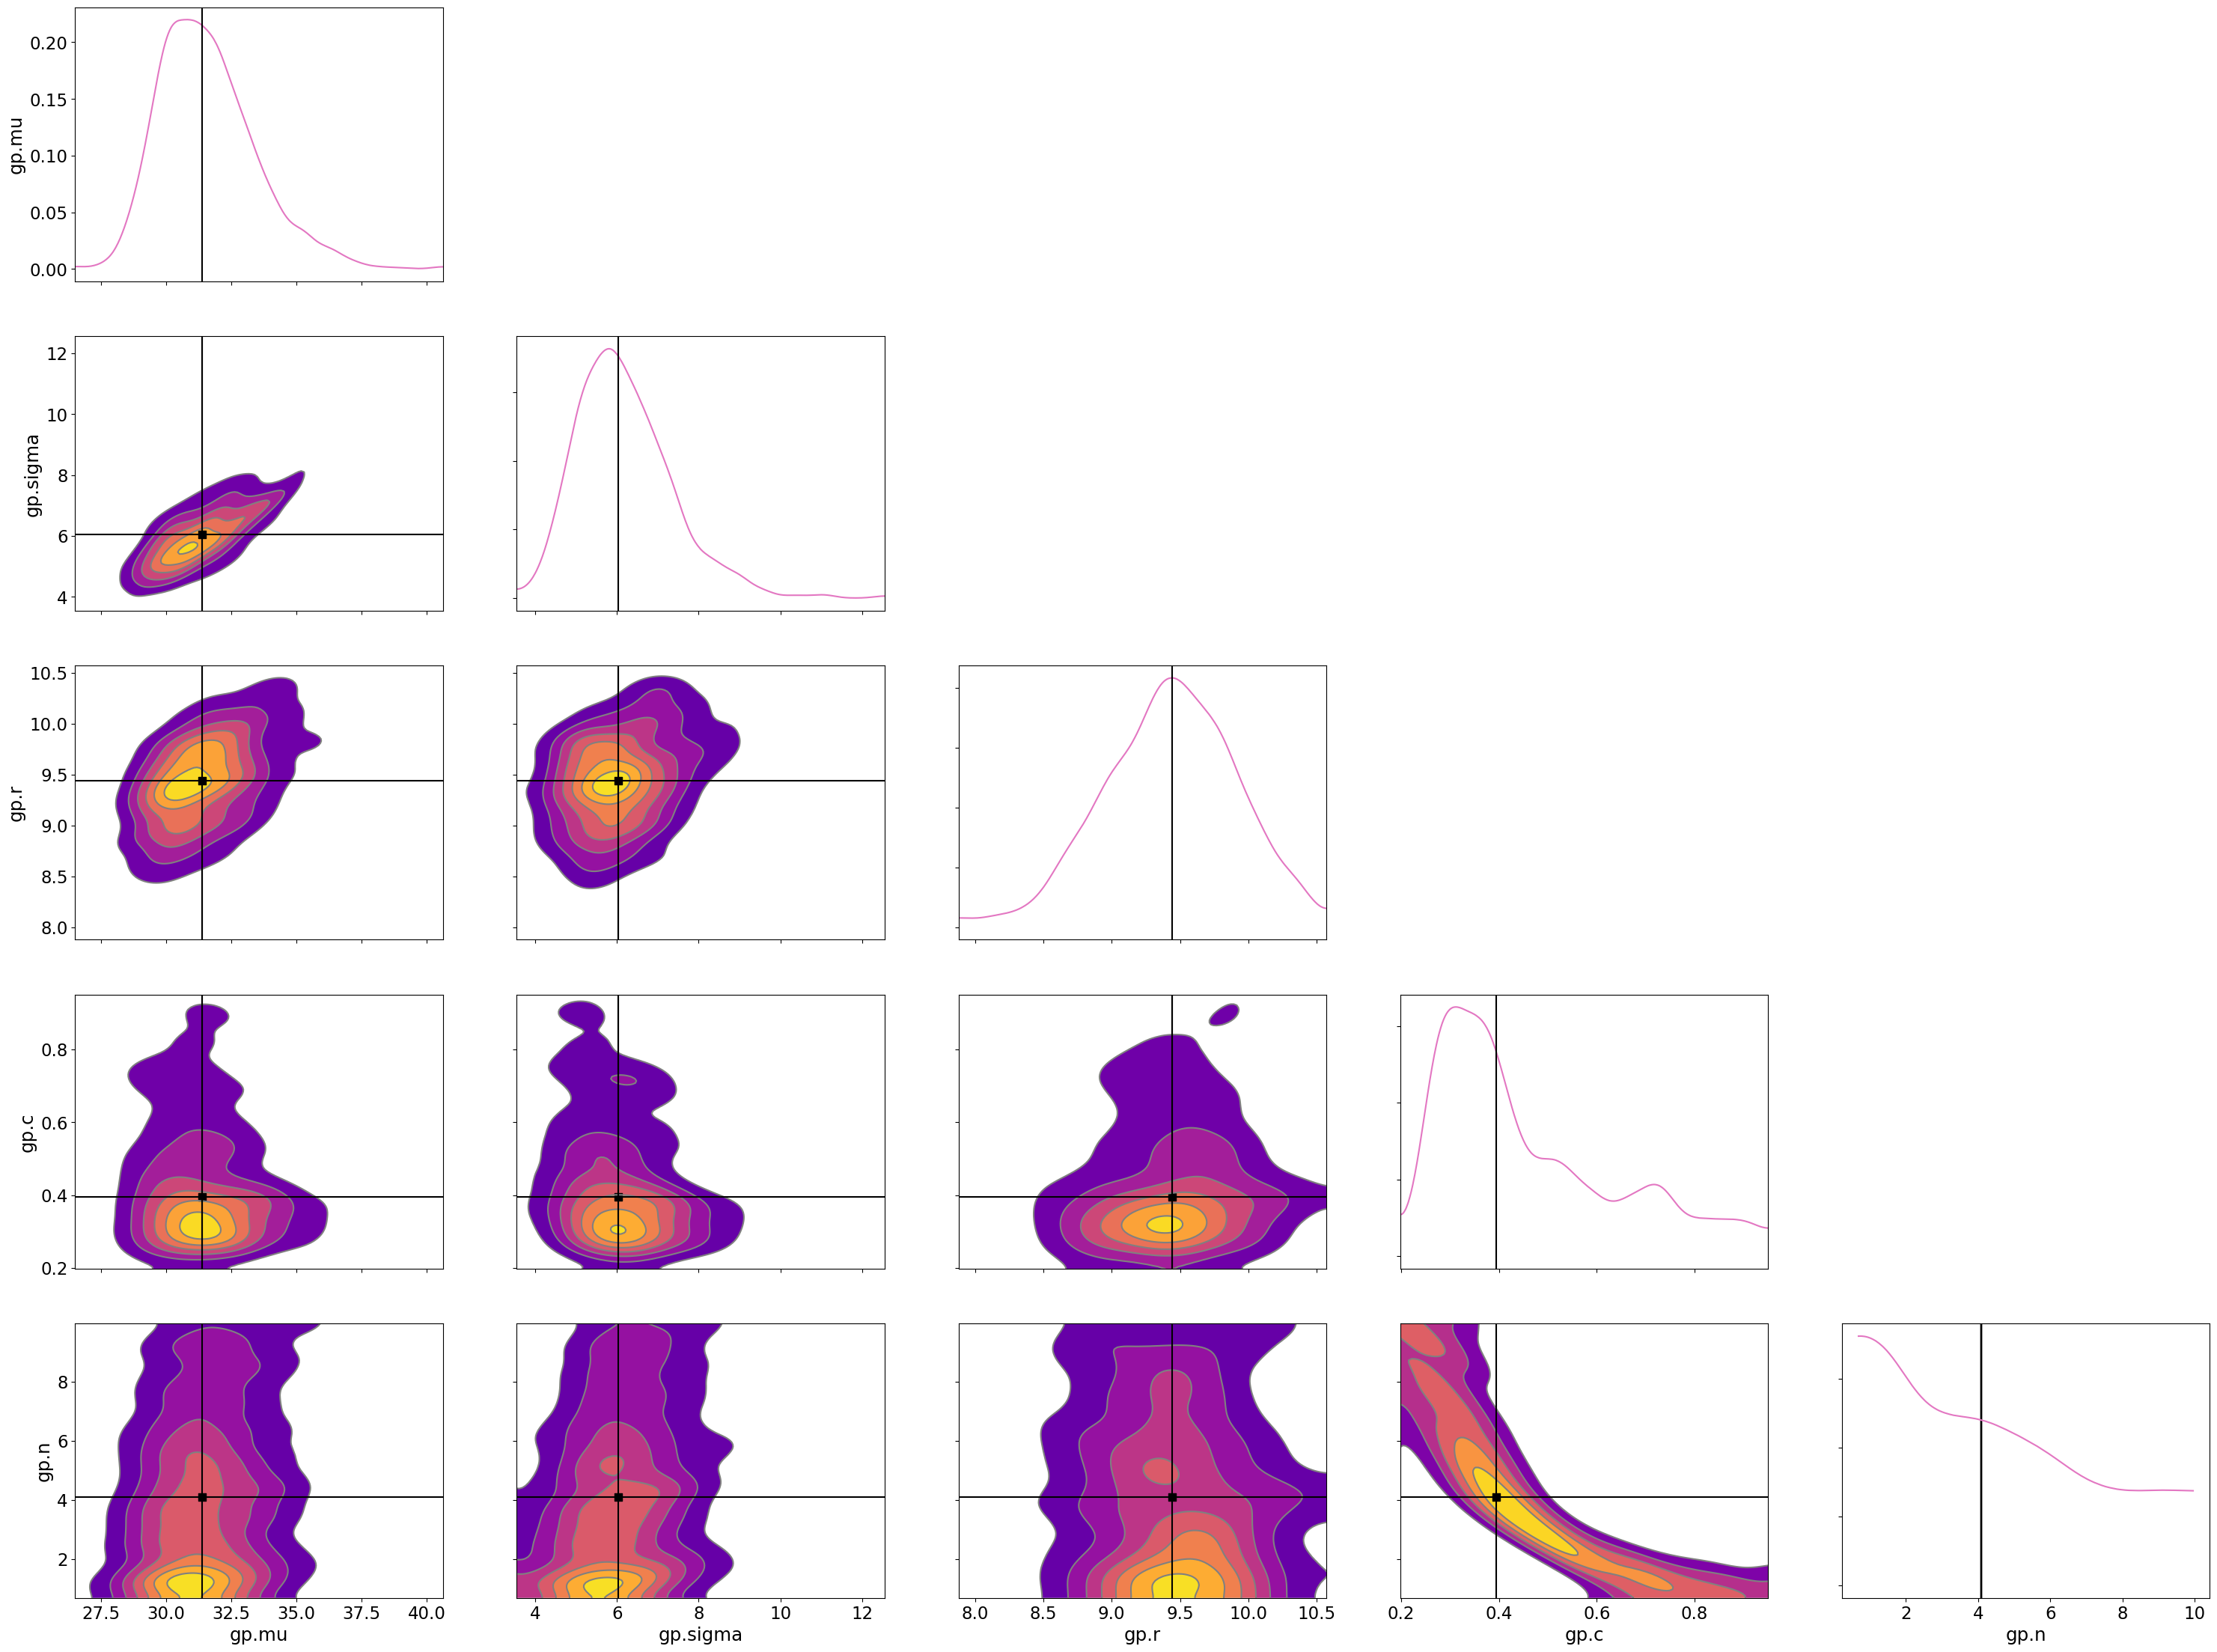

In [26]:
az.plot_pair(
    samples_fromfile.posterior, 
    var_names=['gp.mu', 'gp.sigma', 'gp.r', 'gp.c', 'gp.n'], 
    kind='kde', 
    marginals=True, 
    textsize=16.5, 
    kde_kwargs={'contourf_kwargs':{'color':'C6','cmap':plt.cm.plasma}, 'fill_kwargs':{'alpha': 0.5}},
    divergences=True,
    marginal_kwargs={'color': "C6"},
    point_estimate='median'
    )

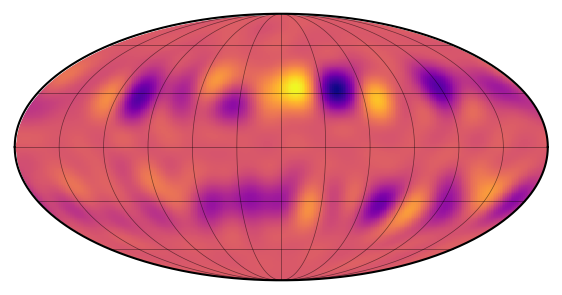

In [27]:
map_inf = starry.Map(15,2)
map_inf[:,:] = np.mean(samples_fromfile.posterior[f'max_map'][0].values, axis=0)
map_inf.show(projection='moll')

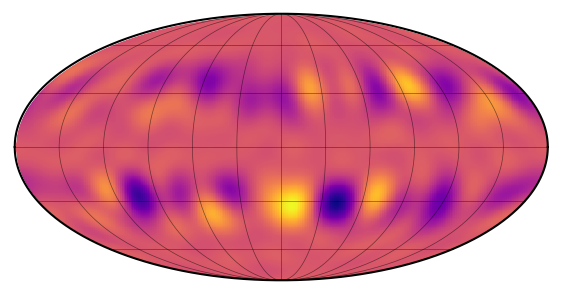

In [28]:
map_true = starry.Map(15,2)

map_true[:,:] = y_true
map_true.show(projection='moll')

Text(0, 0.5, 'probability')

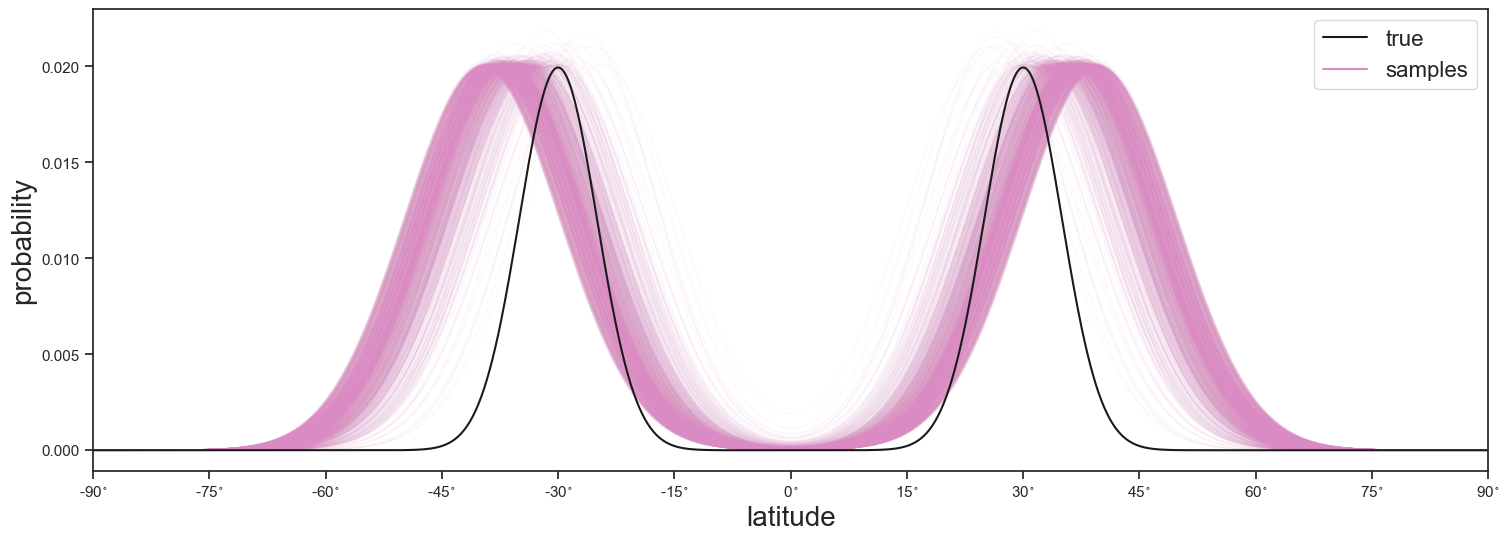

In [155]:
from scipy.stats import norm as Normal

lat=np.linspace(-90., 90., 1000)
nsamples=1000
fig, ax = plt.subplots(1)
fig.set_size_inches(18, 6)
pdf = 0.5 * (
        Normal.pdf(lat, params['gp.mu']['truth'], params['gp.sigma']['truth'])
        + Normal.pdf(lat, -params['gp.mu']['truth'],  params['gp.sigma']['truth'])
    ) / 2
for k in range(nsamples):
    ax.plot(lat, 0.5*(Normal.pdf(lat, samples_fromfile.posterior['gp.mu'][0][k], samples_fromfile.posterior['gp.sigma'][0][k])+Normal.pdf(lat, -samples_fromfile.posterior['gp.mu'][0][k], samples_fromfile.posterior['gp.sigma'][0][k])),'C6',lw=1, alpha=0.05, zorder=-1)
ax.plot(lat, pdf,'k',label='true')
ax.plot(lat, np.nan * lat, "C6-", label="samples")
ax.legend(loc="upper right", fontsize=16)
ax.set_xlim(-90, 90)
xticks = [-90, -75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75, 90]
ax.set_xticks(xticks)
ax.set_xticklabels(["{:d}$^\circ$".format(xt) for xt in xticks])
ax.set_xlabel("latitude", fontsize=20)
ax.set_ylabel("probability", fontsize=20)

# plt.savefig("figures/experiment-1-active-lats.pdf", bbox_inches="tight", dpi=300)

In [20]:
import pandas as pd

In [21]:
data_dict = {var: samples_fromfile.posterior[var].values.flatten() for var in free}
samples_df = pd.DataFrame(data_dict, columns=free)

In [22]:
samples_df['star.inc'] = 180-samples_df['star.inc'] # cheating here cause we know about the inclination-obliquity degeneracy

In [23]:
samples_df['star.obl'] = -samples_df['star.obl'] # cheating here cause we know about the inclination-obliquity degeneracy

In [42]:
custom_labels = {
    'planet.inc': r'$i_p$',
    'planet.ecc': r'$e$',
    'planet.porb': r'$P$',
    'planet.t0': r'$t_0$',
    'planet.r': r'$R_p/R_\star$',
    'star.inc': r'$i_\star$',
    'star.u1': r'$u_1$',
    'star.u2': r'$u_2$',
    'star.prot': r'$P_\star$',
    'star.obl': r'$\lambda_\star$',
    'gp.mu': r'$\mu_\phi$',
    'gp.sigma': r'$\sigma^2_\phi$',
    'gp.r': r'$\mathbb{r}$',
    'gp.c': r'$\mathbb{c}$',
    'gp.n': r'$\mathbb{n}$'
}

In [110]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,  # Slightly smaller font for the expanded plot
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "mathtext.fontset": "stix",  # Use STIX fonts for math (similar to LaTeX)
    "font.serif": ["STIXGeneral", "DejaVu Serif"]
})

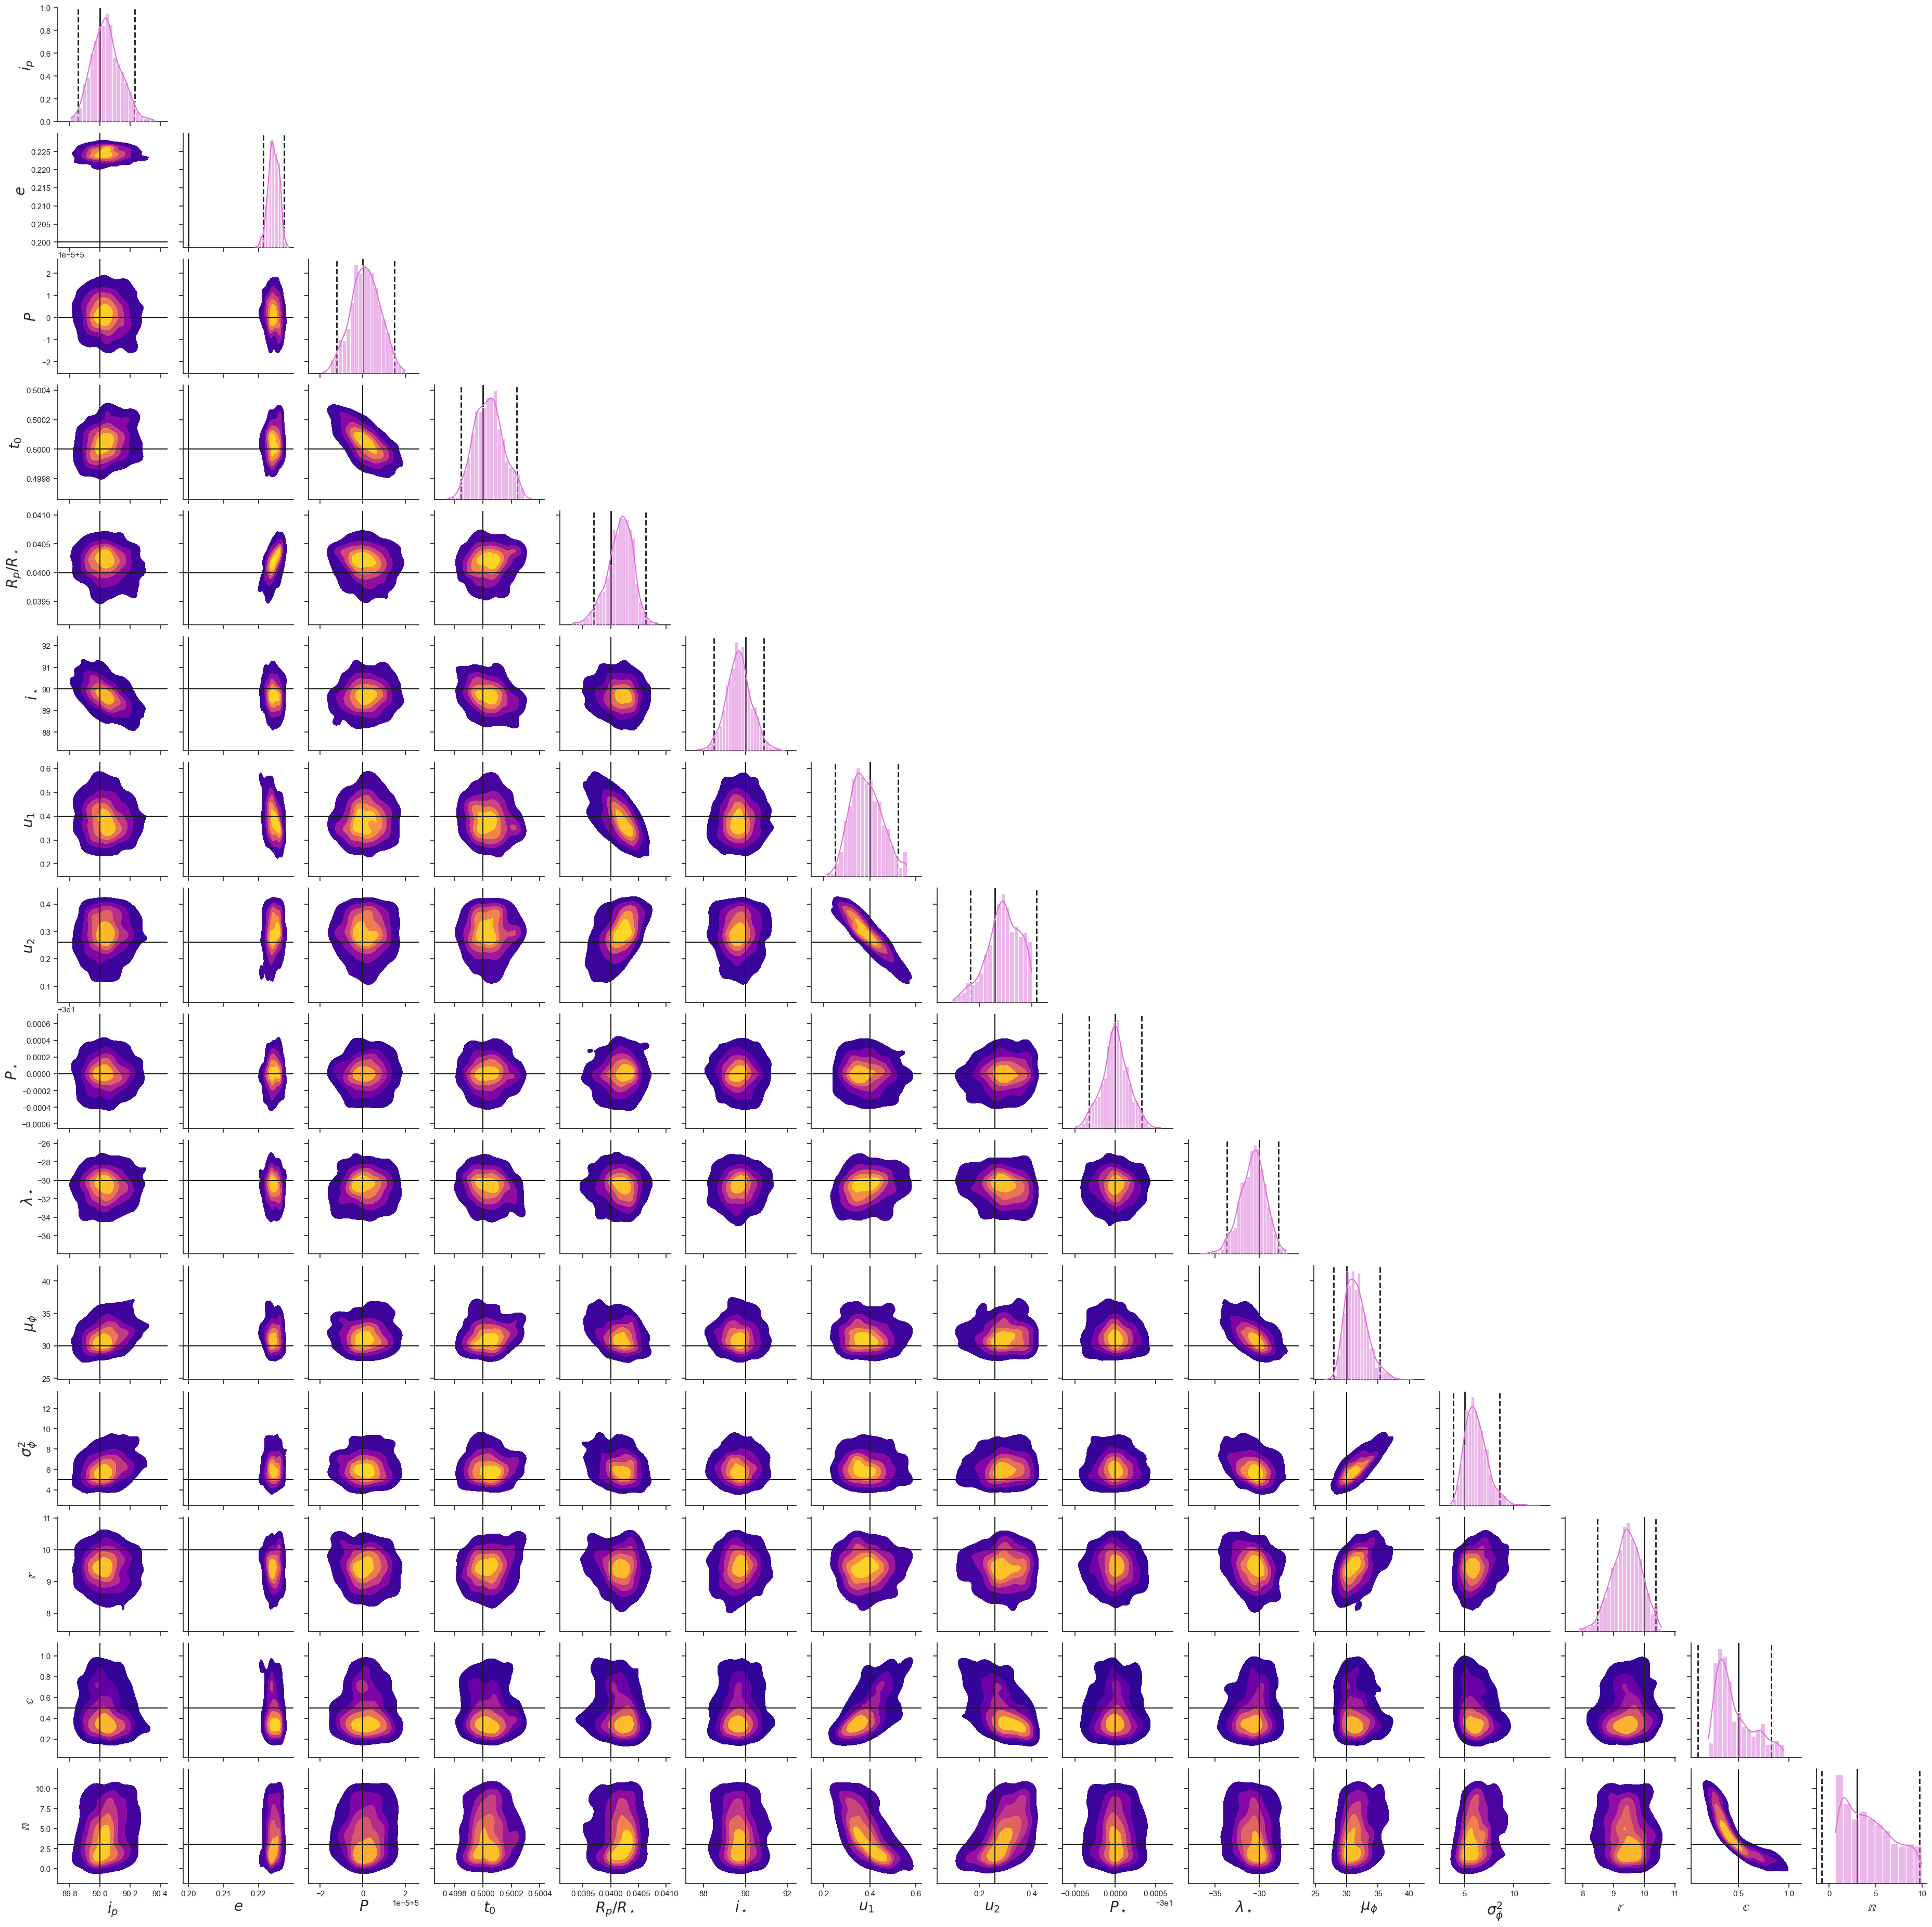

In [47]:
import pandas as pd
import seaborn as sns
sns.set(style='ticks')

# Create the pair grid
g = sns.PairGrid(samples_df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the lower triangle
g.map_lower(sns.kdeplot, cmap='plasma', levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g.map_upper(remove_upper)

for i, var in enumerate(free):
    truth = params[var]['truth']
    # if var == 'star.inc':
    #     truth = 180 - params[var]['truth']
    # if var == 'star.obl':
    #     truth = - params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=2)
    # g.axes[i, i].axhline(truth, color='k', linestyle='-')

    std = np.std(samples_df[var])
    mean = np.mean(samples_df[var])
    sigma_plus = mean + 2 * std
    sigma_minus = mean - 2 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(free):
    for j, x_var in enumerate(free):
        if j < i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']

            # if y_var == 'star.inc':
            #     truth_y = 180 - params[y_var]['truth']
            # if y_var == 'star.obl':
            #     truth_y = - params[y_var]['truth']

            # if x_var == 'star.inc':
            #     truth_x = 180 - params[x_var]['truth']
            # if x_var == 'star.obl':
            #     truth_x = - params[x_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

for i, var in enumerate(free):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

plt.savefig("figures/experiment-1-corner-all.pdf", bbox_inches="tight", dpi=300)

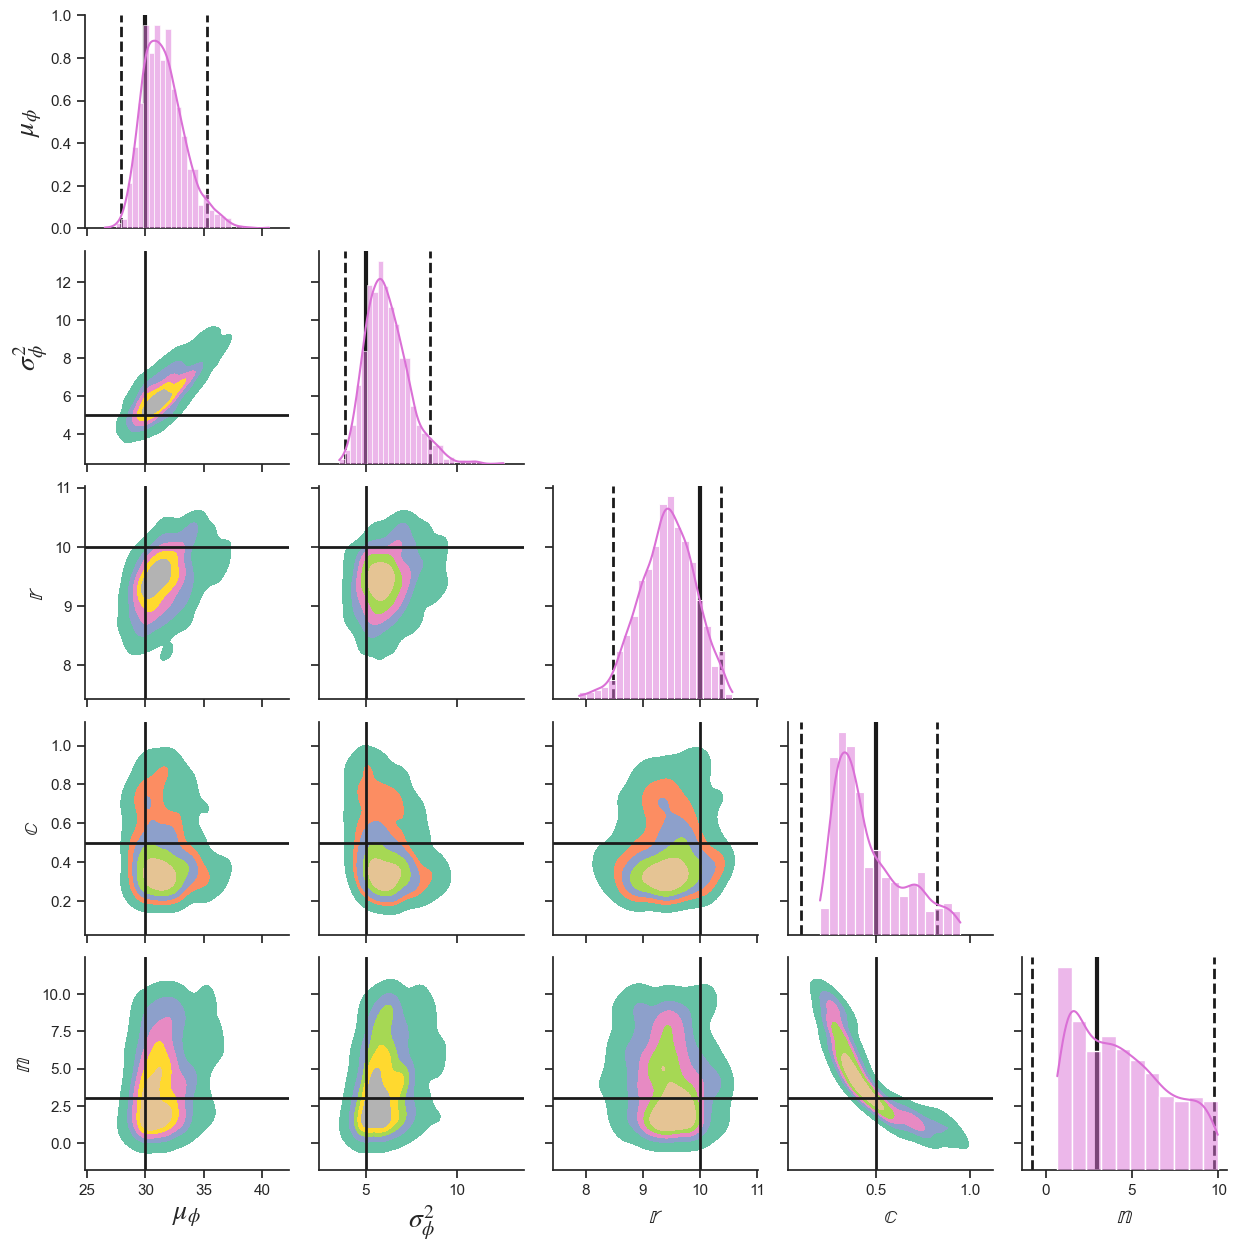

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style='ticks')

# Filter the dataframe to include only the desired columns
desired_columns = ['gp.mu', 'gp.sigma', 'gp.r', 'gp.c', 'gp.n']
filtered_df = samples_df[desired_columns]

# Create the pair grid
g = sns.PairGrid(filtered_df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the lower triangle
g.map_lower(sns.kdeplot, cmap='Set2', levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g.map_upper(remove_upper)

for i, var in enumerate(desired_columns):
    truth = params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=3)

    std = np.std(filtered_df[var])
    mean = np.mean(filtered_df[var])
    sigma_plus = mean + 2 * std
    sigma_minus = mean - 2 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(desired_columns):
    for j, x_var in enumerate(desired_columns):
        if j < i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-',lw=2)
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-',lw=2)

for i, var in enumerate(desired_columns):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

plt.savefig("figures/experiment-1-corner-gp-params.pdf", bbox_inches="tight", dpi=300)

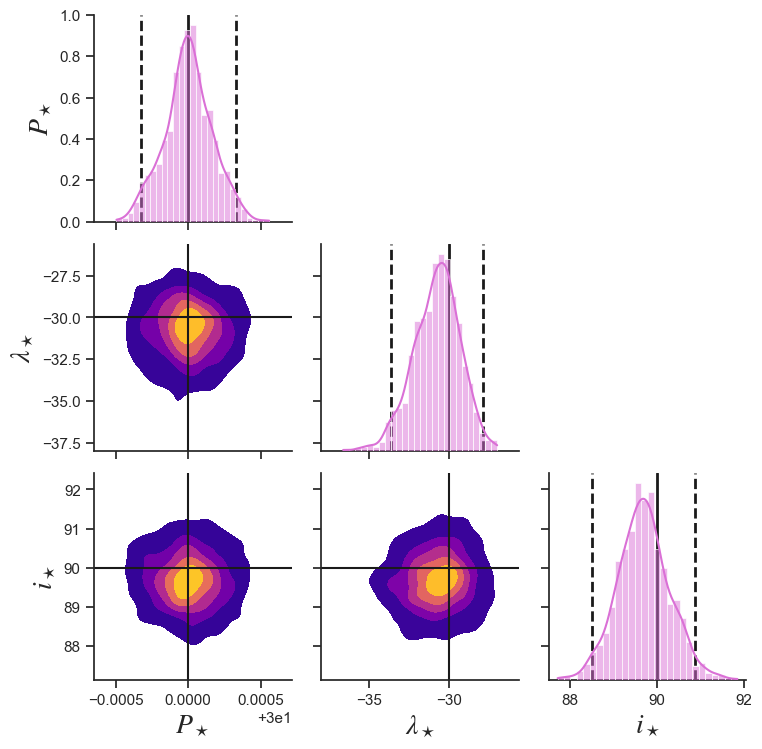

In [102]:
# Filter the dataframe to include only the desired columns
desired_columns = ['star.prot', 'star.obl', 'star.inc']
filtered_df = samples_df[desired_columns]

# Create the pair grid
g = sns.PairGrid(filtered_df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the lower triangle
g.map_lower(sns.kdeplot, cmap='plasma', levels=6, fill=True)

# Custom function to remove upper triangle
def remove_upper(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the upper triangle
g.map_upper(remove_upper)

for i, var in enumerate(desired_columns):
    truth = params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=2)

    std = np.std(filtered_df[var])
    mean = np.mean(filtered_df[var])
    sigma_plus = mean + 2 * std
    sigma_minus = mean - 2 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(desired_columns):
    for j, x_var in enumerate(desired_columns):
        if j < i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

for i, var in enumerate(desired_columns):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)


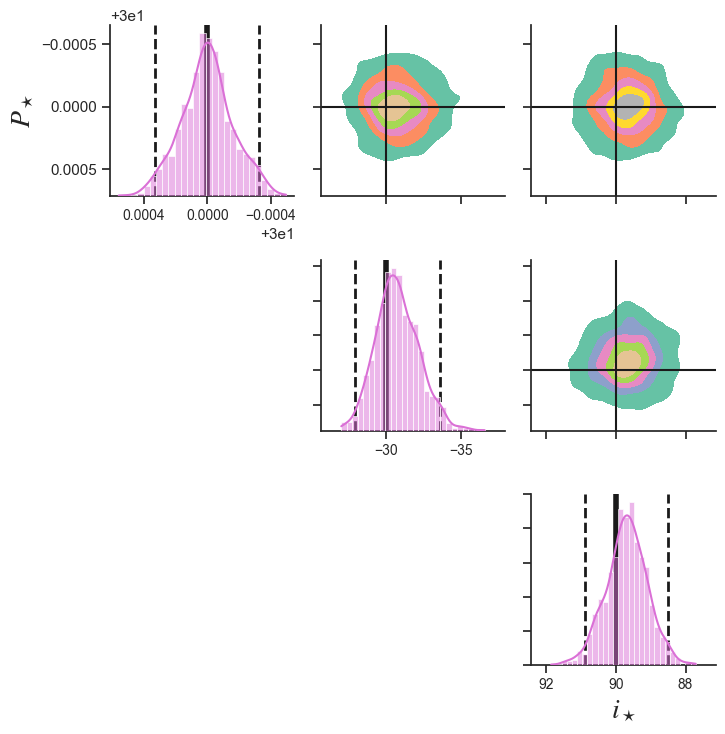

In [107]:
# Filter the dataframe for the desired columns
columns = ['star.prot', 'star.obl', 'star.inc']
df = samples_df[columns]

# Create the pair grid
g = sns.PairGrid(df, diag_sharey=False)

# Map the histograms to the diagonal
g.map_diag(sns.histplot, kde=True, color='orchid')

# Map the 2D contour plots to the upper triangle
g.map_upper(sns.kdeplot, cmap='Set2', levels=6, fill=True)

# Custom function to remove lower triangle
def remove_lower(*args, **kwargs):
    plt.gca().axis('off')

# Remove the scatter plots and empty axes in the lower triangle
g.map_lower(remove_lower)

# Add truth lines and labels
for i, var in enumerate(columns):
    truth = params[var]['truth']
    g.axes[i, i].axvline(truth, color='k', linestyle='-', lw=4)

    std = np.std(df[var])
    mean = np.mean(df[var])
    sigma_plus = mean + 2 * std
    sigma_minus = mean - 2 * std
    g.axes[i, i].axvline(sigma_plus, color='k', linestyle='--', lw=2)
    g.axes[i, i].axvline(sigma_minus, color='k', linestyle='--', lw=2)

# Add truth values as lines to the contour plots
for i, y_var in enumerate(columns):
    for j, x_var in enumerate(columns):
        if j > i:
            truth_x = params[x_var]['truth']
            truth_y = params[y_var]['truth']
            
            g.axes[i, j].axvline(truth_x, color='k', linestyle='-')
            g.axes[i, j].axhline(truth_y, color='k', linestyle='-')

# Add labels
for i, var in enumerate(columns):
    label = custom_labels.get(var, var)
    g.axes[-1, i].set_xlabel(label, fontsize=20)
    g.axes[i, 0].set_ylabel(label, fontsize=20)

# Invert axes to display the plot upside down
for ax in g.axes.flat:
    ax.invert_yaxis()
    ax.invert_xaxis()

# After creating your PairGrid and mapping plots
# Add this to ensure all axes have visible tick labels:

for i, var in enumerate(columns):
    # Get the current diagonal axis (histogram)
    ax = g.axes[i, i]
    
    # Make sure x-axis tick labels are visible
    ax.tick_params(axis='x', which='both', labelsize=10, labelbottom=True)
    
    # Force display of x-axis tick labels
    plt.setp(ax.get_xticklabels(), visible=True)
    
    # Remove scientific notation if needed
    # ax.ticklabel_format(useOffset=False, style='plain', axis='x')
    
    # Optional: set number of ticks on x-axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))

# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig("figures/experiment-1-corner-star-params-inverted.pdf", bbox_inches="tight", dpi=300, transparent=True)

In [43]:
for i, var in enumerate(free):
    truth = params[var]['truth']
    # cheating here cause we know about the inclination-obliquity degeneracy
    if var == 'star.inc':
        truth = 180 - params[var]['truth']
    if var == 'star.obl':
        truth = -params[var]['truth']

    samples = samples_df[var]

    median = np.median(samples)
    std = np.std(samples)
    mean = np.mean(samples)

    lower_bound = np.percentile(samples, 16)
    upper_bound = np.percentile(samples, 84)
    
    print(f'{var}: median = {median}, mean = {mean}, std = {std}, 68% credible interval = [{median - lower_bound}, {upper_bound - median}]')


planet.inc: median = 90.03891474806817, mean = 90.04393054012418, std = 0.0945481611018749, 68% credible interval = [0.08893400039431754, 0.1038814906066392]
planet.ecc: median = 0.22435877171879304, mean = 0.22437122364079964, std = 0.0014957084207940625, 68% credible interval = [0.0014608922089862642, 0.0016137803926798422]
planet.porb: median = 5.000001243524389, mean = 5.000001282458307, std = 6.819531141654005e-06, 68% credible interval = [6.458331122338734e-06, 7.005026804840497e-06]
planet.t0: median = 0.5000394946840907, mean = 0.5000424558160764, std = 9.83189055733716e-05, 68% credible interval = [9.804590767015231e-05, 0.00010051237215280562]
planet.r: median = 0.04018824722095028, mean = 0.04016247203302821, std = 0.00023586493495618218, 68% credible interval = [0.0002470552636683748, 0.0001988951796409802]
star.inc: median = 89.6785823152893, mean = 89.69034281519616, std = 0.5966128301458459, 68% credible interval = [0.5623248492207864, 0.6008095339251014]
star.u1: median

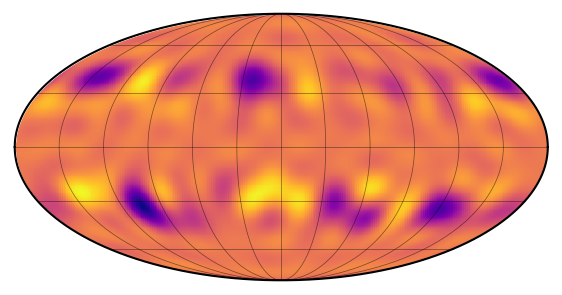

In [ ]:
map_inf = starry.Map(15, 2)
map_inf.inc = np.mean(samples_df['star.inc'][0]) # Note: we cheated here due to the degeneracy
map_inf.obl = np.mean(samples_df['star.obl'][0]) # Note: we cheated here due to the degeneracy
map_inf[1] = np.mean(samples_df['star.u1'][0])
map_inf[2] = np.mean(samples_df['star.u2'][0])
star = starry.Primary(map_inf, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=np.mean(samples_df['star.prot'][0])) 
planet = starry.Secondary(
    starry.Map(0,0),
    inc=np.mean(samples_df['planet.inc'][0]),
    ecc=np.mean(samples_df['planet.ecc'][0]),
    Omega=params["planet.Omega"]["truth"],
    porb=np.mean(samples_df['planet.porb'][0]),
    t0=np.mean(samples_df['planet.t0'][0]),
    r=np.mean(samples_df['planet.r'][0]),
    m=params["planet.m"]["truth"],
    prot=1.0
)

sys = starry.System(star, planet)
xo, yo, zo = sys.position(t)
xo = xo.eval()[1]
yo = yo.eval()[1]
zo = zo.eval()[1]
theta = (360 * t / params["star.prot"]["truth"]) % 360
    
sp = StarryProcess(
    mu=np.mean(samples_df['gp.mu'][0]),
    sigma=np.mean(samples_df['gp.sigma'][0]),
    r=np.mean(samples_df['gp.r'][0]),
    c=np.mean(samples_df['gp.c'][0]),
    n=np.mean(samples_df['gp.n'][0]),
)

nt = len(t)
ssp = StarryStarryProcess(sys, sp)
ssp.compute(t, flux_obs, sigma_flux)

# y_inf = sp.sample_ylm().eval().reshape(-1)
# y_inf[0] += 1
y_inf = ssp.sample_ylm_conditional(t, flux_obs, sigma_flux).eval()[0]
map_inf[:,:] = y_inf

map_inf.show(projection='moll')

Now, let's see how the inferred maps look like if the degeneracy not accounted for.

In [115]:
samples_df['star.inc']

0      89.580197
1      90.106204
2      90.516135
3      89.516540
4      88.907315
         ...    
995    89.584563
996    89.034060
997    89.658162
998    89.841933
999    88.681271
Name: star.inc, Length: 1000, dtype: float64

In [119]:
samples_df['star.inc'][0]

89.58019748374223

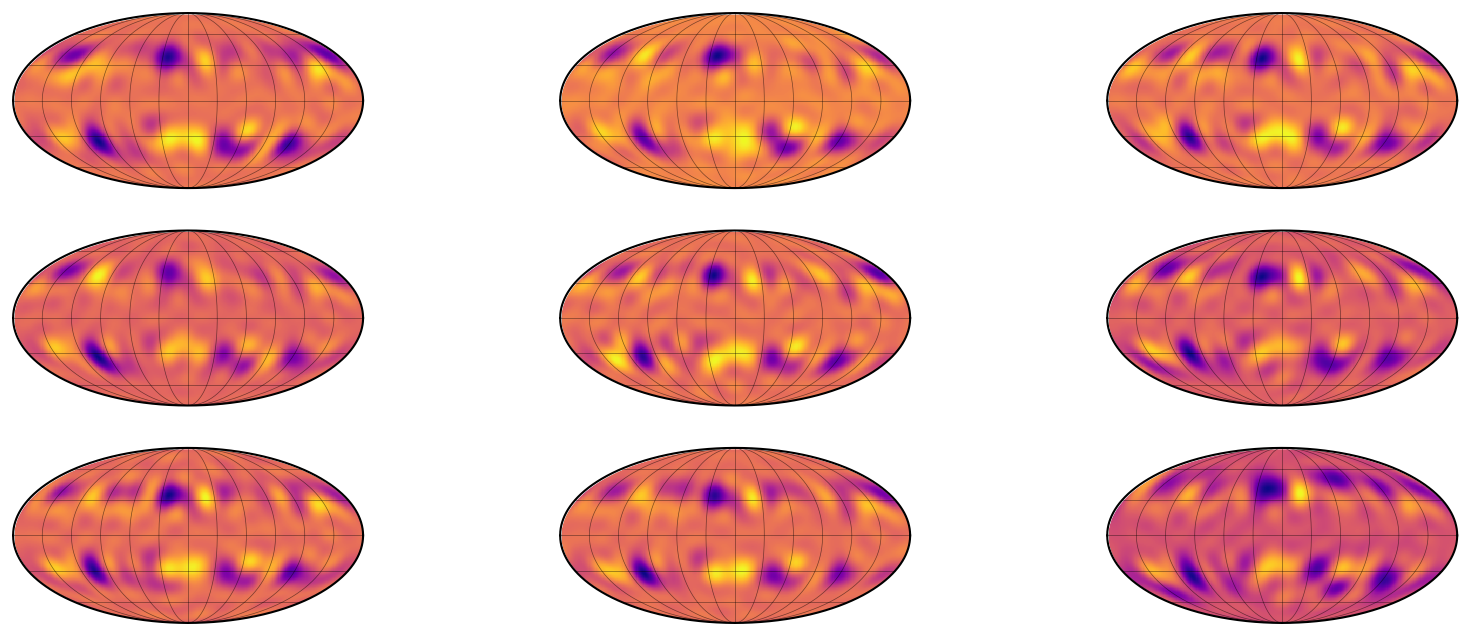

In [24]:
import random
n_samples = 9
fig, ax = plt.subplots(3, 3, figsize=(20, 8))
axes = ax.flatten()
for i in range(n_samples):
    iternum = random.randint(0,999)
    map_inf = starry.Map(15, 2)
    map_inf.inc = samples_df['star.inc'][iternum]
    map_inf.obl = samples_df['star.obl'][iternum]
    map_inf[1] = samples_df['star.u1'][iternum]
    map_inf[2] = samples_df['star.u2'][iternum]
    star = starry.Primary(map_inf, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=samples_df['star.prot'][iternum]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=samples_df['planet.inc'][iternum],
        ecc=samples_df['planet.ecc'][iternum],
        Omega=params["planet.Omega"]["truth"],
        porb=samples_df['planet.porb'][iternum],
        t0=samples_df['planet.t0'][iternum],
        r=samples_df['planet.r'][iternum],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)
        
    sp = StarryProcess(
        mu=samples_df['gp.mu'][iternum],
        sigma=samples_df['gp.sigma'][iternum],
        r=samples_df['gp.r'][iternum],
        c=samples_df['gp.c'][iternum],
        n=samples_df['gp.n'][iternum],
    )

    nt = len(t)
    ssp = StarryStarryProcess(sys, sp)
    ssp.compute(t, flux_obs, sigma_flux)

    # y_inf = sp.sample_ylm().eval().reshape(-1)
    # y_inf[0] += 1
    y_inf = ssp.sample_ylm_conditional(t, flux_obs, sigma_flux).eval()[0]
    map_inf[:,:] = y_inf

    map_inf.show(projection='moll', ax=axes[i])

In [25]:
np.mean(samples_df['star.inc'])

89.69034281519616

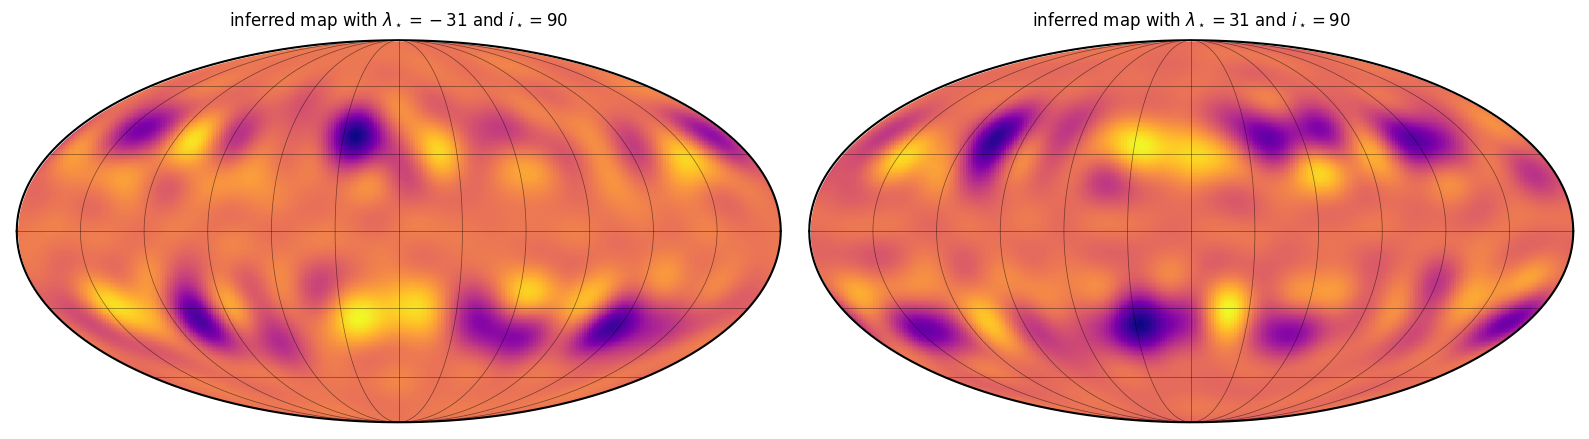

In [26]:
# First map 
map_inf1 = starry.Map(15, 2)
map_inf1.inc = np.mean(samples_df['star.inc'])
map_inf1.obl = np.mean(samples_df['star.obl'])
map_inf1[1] = np.mean(samples_df['star.u1'])
map_inf1[2] = np.mean(samples_df['star.u2'])
star1 = starry.Primary(map_inf1, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=np.mean(samples_df['star.prot'])) 
planet1 = starry.Secondary(
    starry.Map(0,0),
    inc=np.mean(samples_df['planet.inc']),
    ecc=np.mean(samples_df['planet.ecc']),
    Omega=params["planet.Omega"]["truth"],
    porb=np.mean(samples_df['planet.porb']),
    t0=np.mean(samples_df['planet.t0']),
    r=np.mean(samples_df['planet.r']),
    m=params["planet.m"]["truth"],
    prot=1.0
)

sys1 = starry.System(star1, planet1)
xo1, yo1, zo1 = sys1.position(t)
xo1 = xo1.eval()[1]
yo1 = yo1.eval()[1]
zo1 = zo1.eval()[1]
theta1 = (360 * t / params["star.prot"]["truth"]) % 360
    
sp1 = StarryProcess(
    mu=np.mean(samples_df['gp.mu']),
    sigma=np.mean(samples_df['gp.sigma']),
    r=np.mean(samples_df['gp.r']),
    c=np.mean(samples_df['gp.c']),
    n=np.mean(samples_df['gp.n']),
)

nt = len(t)
ssp1 = StarryStarryProcess(sys1, sp1)
ssp1.compute(t, flux_obs, sigma_flux)

y_inf1 = ssp1.sample_ylm_conditional(t, flux_obs, sigma_flux).eval()[0]
map_inf1[:,:] = y_inf1

# Second map 
map_inf2 = starry.Map(15, 2)
map_inf2.inc = 180-np.mean(samples_df['star.inc'])
map_inf2.obl = -np.mean(samples_df['star.obl'])
map_inf2[1] = np.mean(samples_df['star.u1'])
map_inf2[2] = np.mean(samples_df['star.u2'])
star2 = starry.Primary(map_inf2, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=np.mean(samples_df['star.prot'])) 
planet2 = starry.Secondary(
    starry.Map(0,0),
    inc=np.mean(samples_df['planet.inc']),
    ecc=np.mean(samples_df['planet.ecc']),
    Omega=params["planet.Omega"]["truth"],
    porb=np.mean(samples_df['planet.porb']),
    t0=np.mean(samples_df['planet.t0']),
    r=np.mean(samples_df['planet.r']),
    m=params["planet.m"]["truth"],
    prot=1.0
)

sys2 = starry.System(star2, planet2)
xo2, yo2, zo2 = sys2.position(t)
xo2 = xo2.eval()[1]
yo2 = yo2.eval()[1]
zo2 = zo2.eval()[1]
theta2 = (360 * t / params["star.prot"]["truth"]) % 360
    
sp2 = StarryProcess(
    mu=np.mean(samples_df['gp.mu']),
    sigma=np.mean(samples_df['gp.sigma']),
    r=np.mean(samples_df['gp.r']),
    c=np.mean(samples_df['gp.c']),
    n=np.mean(samples_df['gp.n']),
)

ssp2 = StarryStarryProcess(sys2, sp2)
ssp2.compute(t, flux_obs, sigma_flux)

y_inf2 = ssp2.sample_ylm_conditional(t, flux_obs, sigma_flux).eval()[0]
map_inf2[:,:] = y_inf2

# Create a figure with two subplots side by side
fig = plt.figure(figsize=(16, 6))

# First map
ax1 = plt.subplot(1, 2, 1)
map_inf1.show(projection='moll', ax=ax1)
ax1.set_title(rf"inferred map with $\lambda_\star={np.mean(samples_df['star.obl']):.0f}$ and $i_\star={np.mean(samples_df['star.inc']):.0f}$")

# Second map
ax2 = plt.subplot(1, 2, 2)
map_inf2.show(projection='moll', ax=ax2)
ax2.set_title(rf"inferred map with $\lambda_\star={-np.mean(samples_df['star.obl']):.0f}$ and $i_\star={180-np.mean(samples_df['star.inc']):.0f}$")

plt.tight_layout()
plt.savefig("figures/experiment-1-comparison-inferred-maps.pdf", bbox_inches="tight", dpi=300, transparent=True)

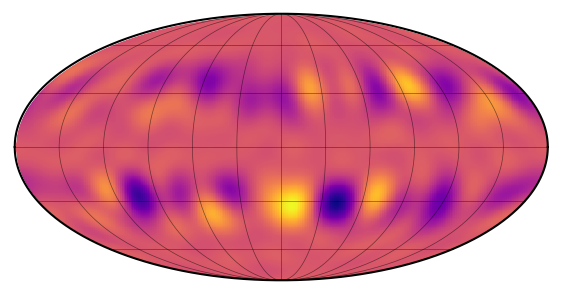

In [29]:
map_true = starry.Map(15, 2)
map_true[:,:] = y_true
map_true.show(projection='moll')

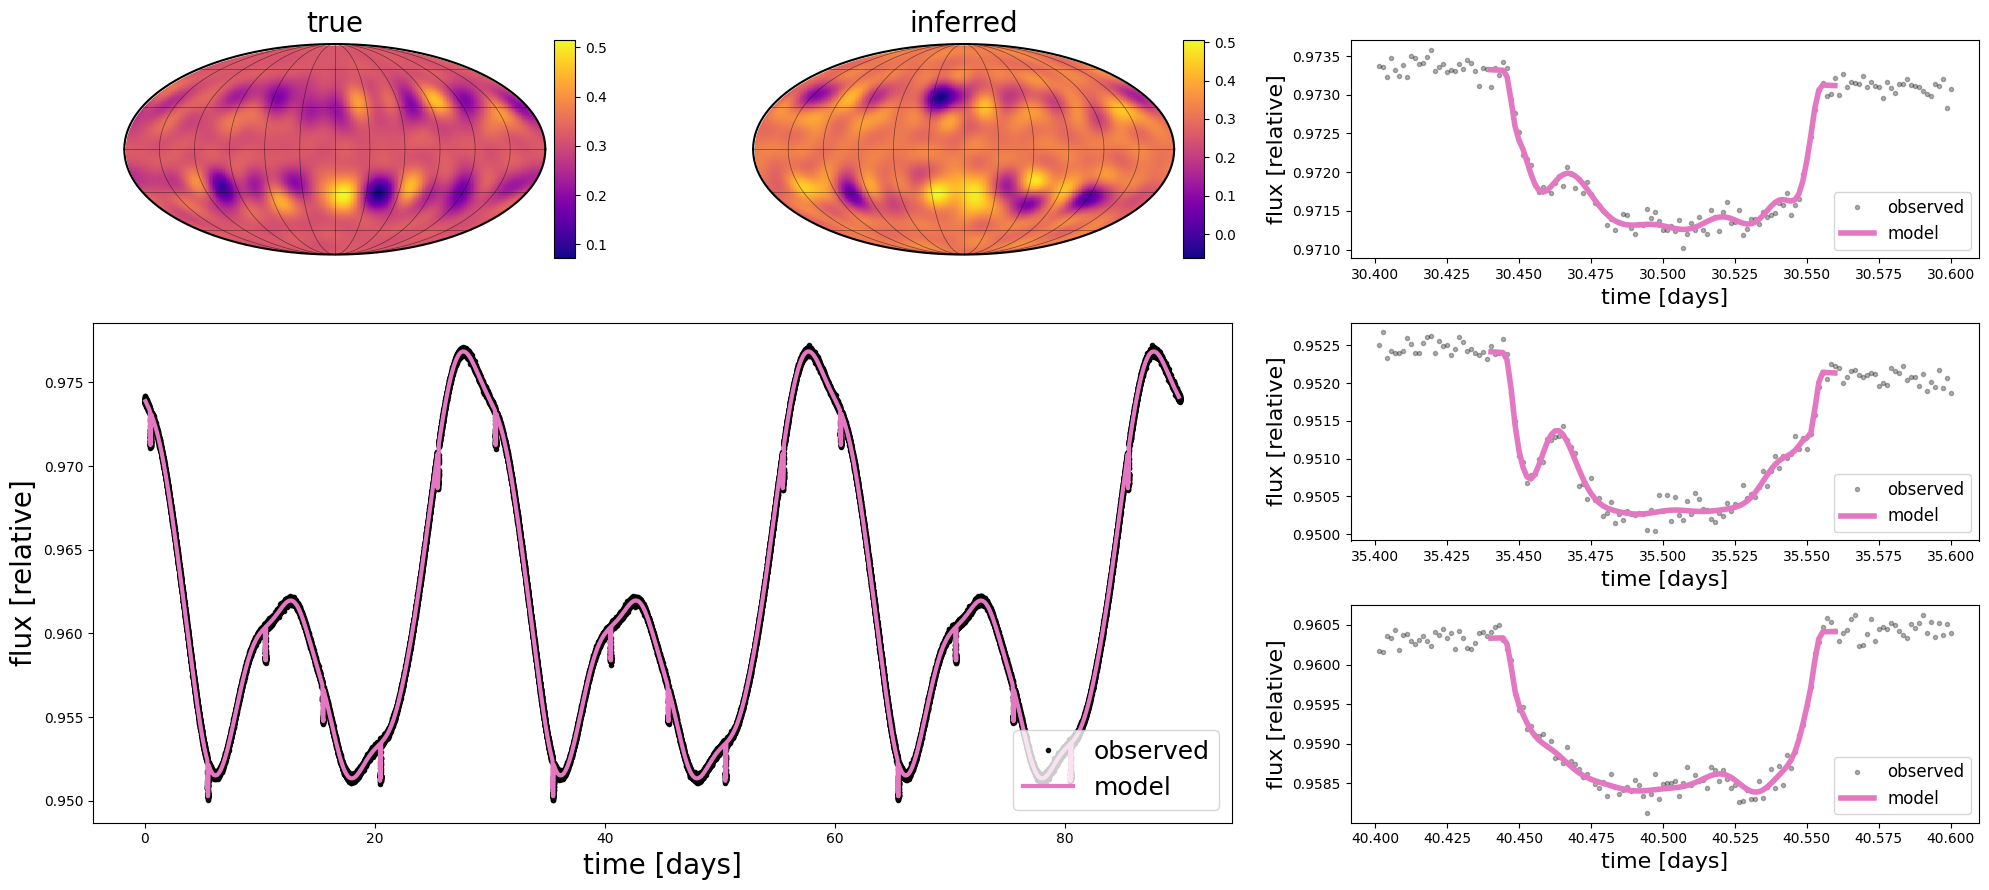

In [ ]:
from matplotlib import colors
cmap = plt.get_cmap("plasma")
cmap.set_under("#666666")
cmap.set_over("w")
cnorm = lambda: colors.Normalize(vmin=0.0)

fig = plt.figure(figsize=(20, 9))  

# Create a 3x4 grid
gs = fig.add_gridspec(3, 4, width_ratios=[1, 1, 0.5, 0.5])

ax = [
    fig.add_subplot(gs[0, 0]),  # Top left
    fig.add_subplot(gs[0, 1]),  # Top right
    fig.add_subplot(gs[1:, :2]),  # Bottom spanning two columns
    fig.add_subplot(gs[0, 2:]),  # Top right, new column
    fig.add_subplot(gs[1, 2:]),  # Middle right, new column
    fig.add_subplot(gs[2, 2:]),  # Bottom right, new column
]

# Show the true map
map_true.show(
    ax=ax[0],
    projection="moll",
    colorbar=True,
)
ax[0].set_title('true', fontsize=20)

# # Show the inferred map
map_inf.show(
    ax=ax[1],
    projection="moll",
    colorbar=True,
    origin='lower'
)

ax[1].set_title('inferred', fontsize=20)

# Show the flux model in the bottom panel
ax[2].plot(t, flux_obs, "k.", alpha=0.9, label="observed")
ax[2].plot(t_, np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0), "C6", label="model", alpha=1, lw=3)
ax[2].legend(fontsize=18, loc="lower right")
ax[2].set_xlabel("time [days]", fontsize=20)
ax[2].set_ylabel("flux [relative]", fontsize=20)

# Add three more panels to the right
for i in range(3, 6):
    idx = (t > planet.t0.eval()+(i+3)*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+(i+3)*planet.porb.eval()+0.1)
    ax[i].plot(t[idx], flux_obs[idx], "k.", alpha=0.3, label="observed")
    idx = (t_ > planet.t0.eval()+(i+3)*planet.porb.eval()-0.1) &  (t_<planet.t0.eval()+(i+3)*planet.porb.eval()+0.1)
    ax[i].plot(t_[idx], np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0)[idx], "C6", label="model", alpha=1, lw=4)
    ax[i].legend(fontsize=12, loc="lower right")
    ax[i].set_xlabel("time [days]", fontsize=16)
    ax[i].set_ylabel("flux [relative]", fontsize=16)

plt.tight_layout()

plt.savefig("figures/experiment-1-map-comparison.pdf", bbox_inches="tight", dpi=300)

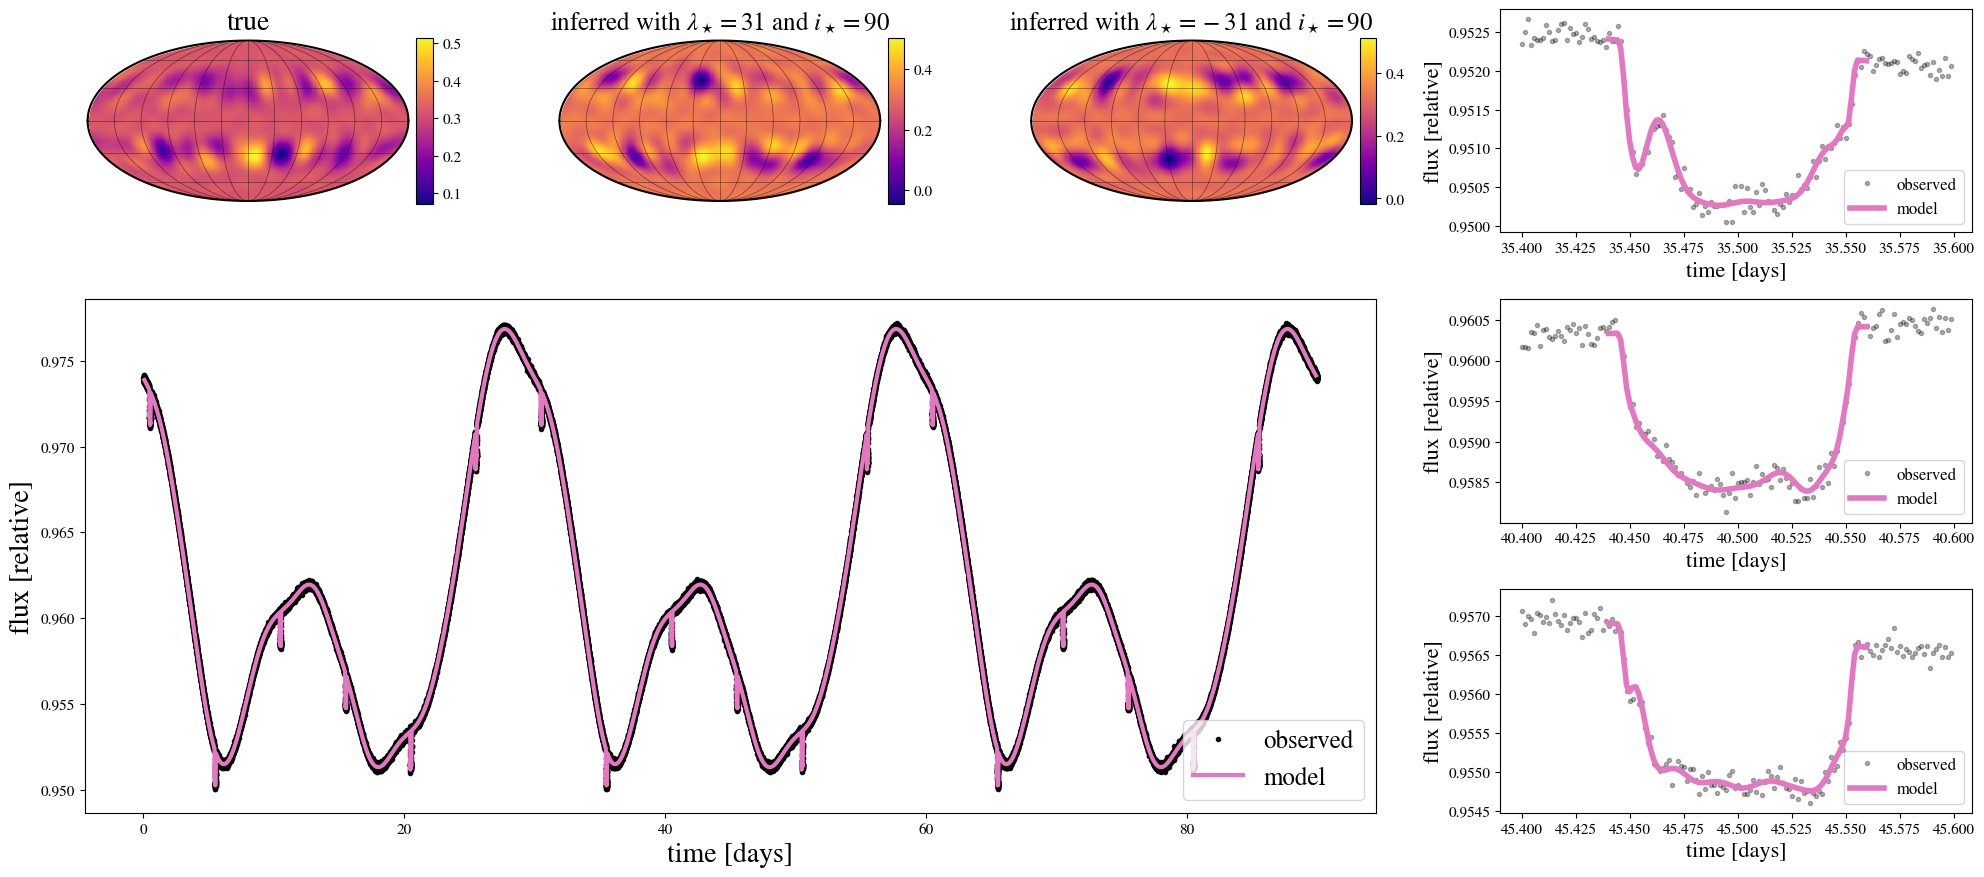

In [ ]:
from matplotlib import colors
cmap = plt.get_cmap("plasma")
cmap.set_under("#666666")
cmap.set_over("w")
cnorm = lambda: colors.Normalize(vmin=0.0)

fig = plt.figure(figsize=(20, 9))  

# Create a 3x4 grid
gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 1, 0.5, 0.5])

ax = [
    fig.add_subplot(gs[0, 0]),  # Top left
    fig.add_subplot(gs[0, 1]),  # Top middle
    fig.add_subplot(gs[0, 2]),  # Top right
    fig.add_subplot(gs[1:, :3]),  # Bottom spanning two columns
    fig.add_subplot(gs[0, 3:]),  # Top right, new column
    fig.add_subplot(gs[1, 3:]),  # Middle right, new column
    fig.add_subplot(gs[2, 3:]),  # Bottom right, new column
]

# Show the true map
map_true.show(
    ax=ax[0],
    projection="moll",
    colorbar=True,
)
ax[0].set_title('true', fontsize=20)

# # Show the inferred map
map_inf1.show(
    ax=ax[1],
    projection="moll",
    colorbar=True,
    origin='lower'
)

map_inf2.show(
    ax=ax[2],
    projection="moll",
    colorbar=True,
    origin='lower'
)

ax[1].set_title(rf"inferred with $\lambda_\star={-np.mean(samples_df['star.obl'][0]):.0f}$ and $i_\star={180-np.mean(samples_df['star.inc'][0]):.0f}$", fontsize=18)
ax[2].set_title(rf"inferred with $\lambda_\star={np.mean(samples_df['star.obl'][0]):.0f}$ and $i_\star={np.mean(samples_df['star.inc'][0]):.0f}$", fontsize=18)

# Show the flux model in the bottom panel
ax[3].plot(t, flux_obs, "k.", alpha=0.9, label="observed")
ax[3].plot(t_, np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0), "C6", label="model", alpha=1, lw=3)
ax[3].legend(fontsize=18, loc="lower right")
ax[3].set_xlabel("time [days]", fontsize=20)
ax[3].set_ylabel("flux [relative]", fontsize=20)

# Add three more panels to the right
for i in range(4, 7):
    idx = (t > planet.t0.eval()+(i+3)*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+(i+3)*planet.porb.eval()+0.1)
    ax[i].plot(t[idx], flux_obs[idx], "k.", alpha=0.3, label="observed")
    idx = (t_ > planet.t0.eval()+(i+3)*planet.porb.eval()-0.1) &  (t_<planet.t0.eval()+(i+3)*planet.porb.eval()+0.1)
    ax[i].plot(t_[idx], np.mean(samples_fromfile.posterior['flux_model'][0].values, axis=0)[idx], "C6", label="model", alpha=1, lw=4)
    ax[i].legend(fontsize=12, loc="lower right")
    ax[i].set_xlabel("time [days]", fontsize=16)
    ax[i].set_ylabel("flux [relative]", fontsize=16) 

plt.tight_layout()

plt.savefig("figures/experiment-1-map-comparison.pdf", bbox_inches="tight", dpi=300)

<ErrorbarContainer object of 3 artists>

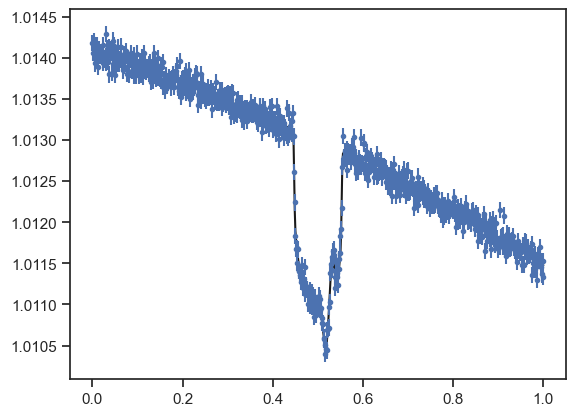

In [92]:
sel = np.abs(t) < 10/10
plt.plot(t[sel], flux_true[sel], color='k')
plt.errorbar(t[sel], flux_obs[sel], yerr=sigma_flux[sel], fmt='.')

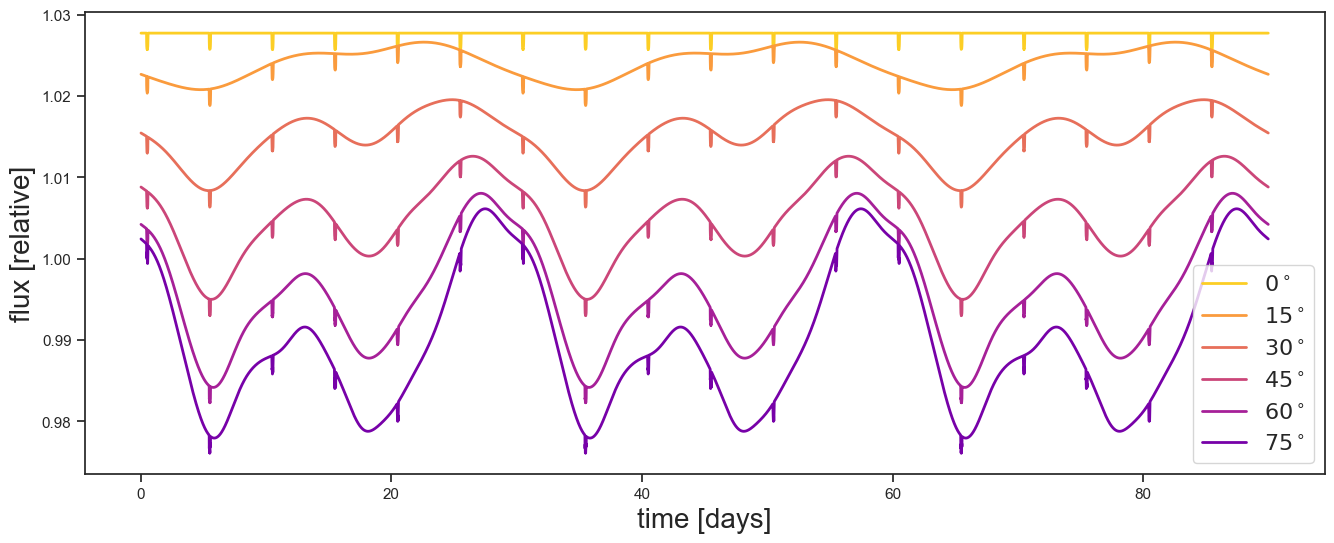

In [102]:
starry.config.lazy = True
incs = [0,15,30,45,60,75,90]

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(incs) - 1))

plt.figure(figsize=(16,6))

for k in range(len(obls)):
    map = starry.Map(15, 2)
    map.inc = incs[k]
    map.obl = 0.0
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)
    xo, yo, zo = sys.position(t)
    xo = xo.eval()[1]
    yo = yo.eval()[1]
    zo = zo.eval()[1]
    theta = (360 * t / params["star.prot"]["truth"]) % 360
        
    sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
    y_true = sp.sample_ylm().eval()[0,:]
    y_true[0] = 1.0

    flux_true = sys.design_matrix(t).eval()[:, :-1] @ y_true
    sigma_flux = 1e-4*np.ones_like(flux_true)

    flux_obs = flux_true + sigma_flux*rng.normal(size=nt)

    # ssp = StarryStarryProcess(sys, sp, nt, len(pri.map.y.eval()))

    map[:,:] = y_true
    # map.show(ax=ax[0][k]) 

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)

    sel = np.abs(t) < 1
    plt.plot(t, flux_true, color=color(k), lw=2, label=rf"${incs[k]}^\circ$")
    plt.legend(fontsize=16)

plt.ylabel("flux [relative]", fontsize=20)
plt.xlabel("time [days]", fontsize=20)
plt.savefig("figures/inclinations.pdf", bbox_inches="tight", dpi=300)


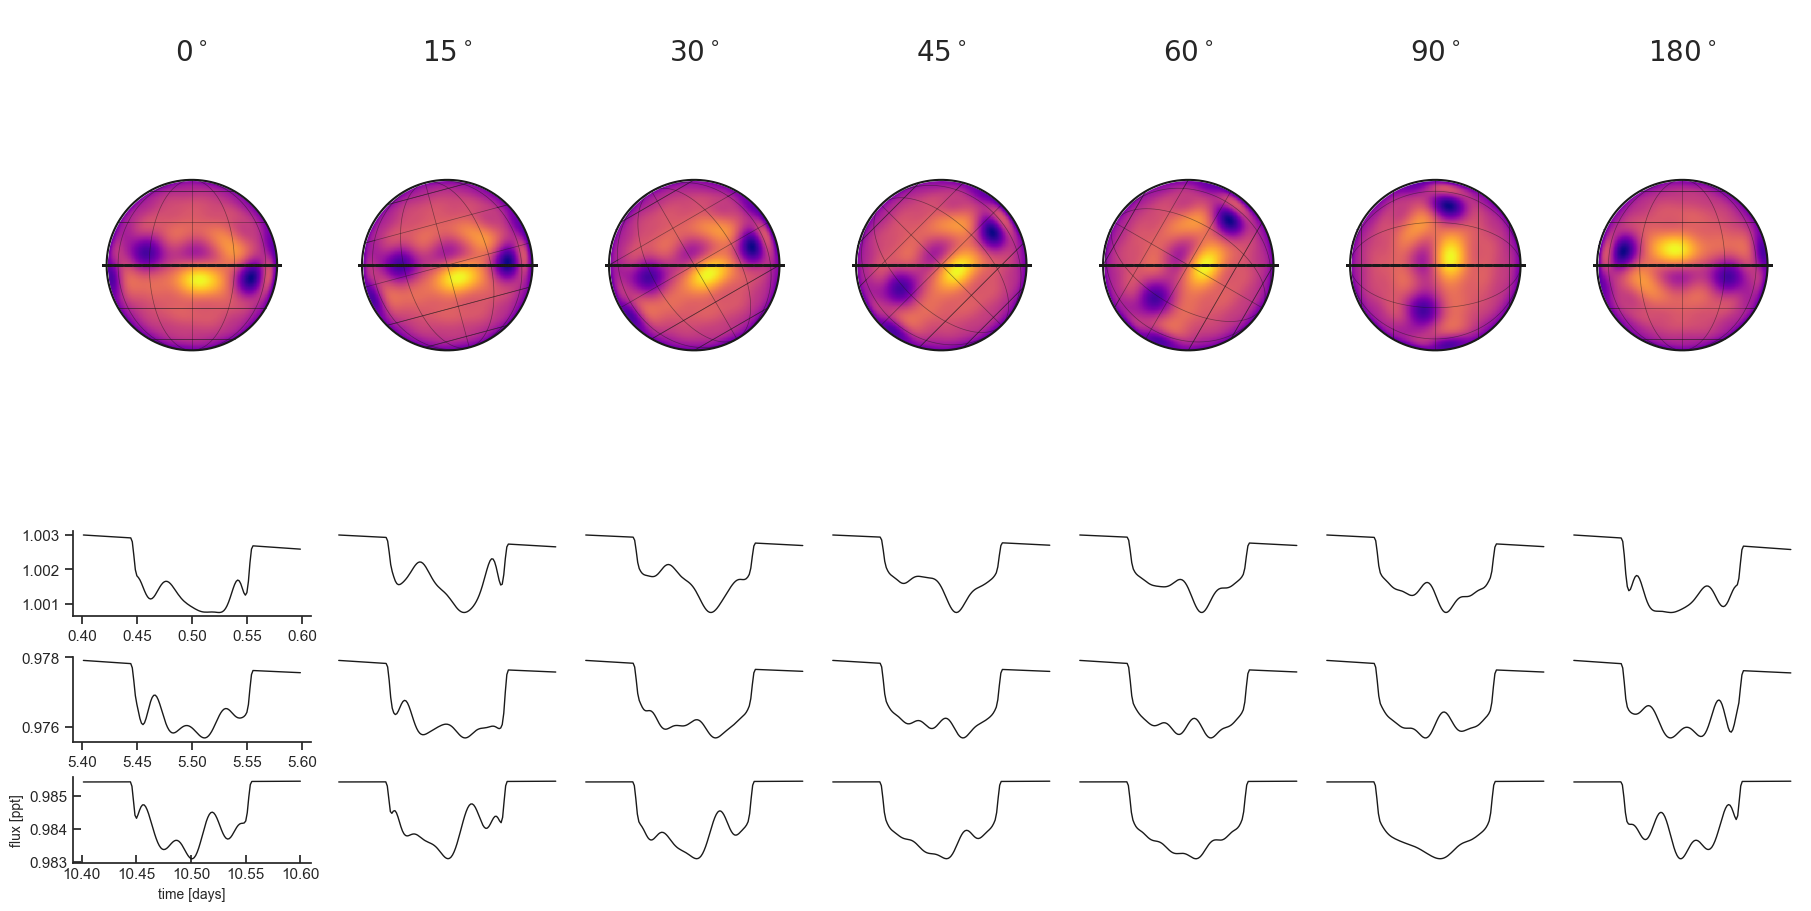

In [132]:
starry.config.lazy = True
obls = [0,15,30,45,60,90,180]

ntransits = int(np.ceil(t[-1] / params['planet.porb']['truth'])) // 6
for n in range(ntransits):
        t0 = 0 + n * params['planet.porb']['truth']
        idx |= ((t > t0 - 0.01) & (t < t0 + 0.01))

cmap = plt.get_cmap("plasma_r")
color = lambda i: cmap(0.1 + 0.8 * i / (len(6) - 1))

fig, ax = plt.subplots(
    # 2+ntransits,
    1+ntransits,
    len(obls),
    figsize=(18, 9),
    gridspec_kw={
        "height_ratios": [3]+[0.5]*ntransits,
    },
    constrained_layout=True,
)


map = starry.Map(15, udeg=2, inc = 90)
sp = StarryProcess(
        a=params["gp.a"]["truth"],
        b=params["gp.b"]["truth"],
        r=params["gp.r"]["truth"],
        c=params["gp.c"]["truth"],
        n=params["gp.n"]["truth"],
    )
y_true = sp.sample_ylm().eval()[0,:]
y_true[0] = 1.0

map[:,:] = y_true

for k in range(len(obls)):
    map.obl = obls[k]
    map[1] = params["star.u1"]["truth"]
    map[2] = params["star.u2"]["truth"]
    star = starry.Primary(map, r=params["star.r"]["truth"], m=params["star.m"]["truth"], prot=params["star.prot"]["truth"]) 
    planet = starry.Secondary(
        starry.Map(0,0),
        inc=params["planet.inc"]["truth"],
        ecc=params["planet.ecc"]["truth"],
        Omega=params["planet.Omega"]["truth"],
        porb=params["planet.porb"]["truth"],
        t0=params["planet.t0"]["truth"],
        r=params["planet.r"]["truth"],
        m=params["planet.m"]["truth"],
        prot=1.0
    )

    sys = starry.System(star, planet)

    flux_true = sys.flux(t, total=False)[0].eval()

    map.show(ax=ax[0][k])

    xo, yo, zo = sys.position(t)
    xo = xo[1].eval()
    yo = yo[1].eval()
    zo = zo[1].eval()
        
    idx = (zo > 0) | (xo ** 2 + yo ** 2 > 1)
    ax[0][k].plot(xo[idx], yo[idx], "k.", ms=1);
    ax[0][k].set_aspect(1)
    ax[0][k].set_ylim(-3, 3)

    for i in range(ntransits):

        idx = (t > planet.t0.eval()+i*planet.porb.eval()-0.1) &  (t<planet.t0.eval()+i*planet.porb.eval()+0.1)
        ax[i+1][k].plot(t[idx], flux_true[idx], color='k', lw=1)
    
        if k == 0:
                ax[i+1, k].spines["top"].set_visible(False)
                ax[i+1, k].spines["right"].set_visible(False)
        else:
            ax[i+1, k].axis("off")
        if k == 0 and i==ntransits-1:
                ax[i+1, k].set_xlabel("time [days]", fontsize=10)
                ax[i+1, k].set_ylabel("flux [ppt]", fontsize=10)
                ax[i+1, k].tick_params(direction="in")
            
    # Add annotation above each column
    ax[0, k].text(0.5, 0.9, rf"${obls[k]}^\circ$", transform=ax[0, k].transAxes,
                 fontsize=20, ha='center')
# plt.tight_layout()
# plt.subplots_adjust(top=0.5)
plt.savefig("figures/obliquities.pdf", bbox_inches="tight", dpi=300)